# Validasi Simulasi Asosiasi Gender pada Representasi Pekerjaan Menggunakan SC-WEAT

Notebook ini memvalidasi implementasi komputasional SC-WEAT menggunakan ruang embedding sintetis yang dibentuk secara terkendali. Generator dirancang agar tidak bergantung pada urutan pekerjaan, pusat semantik kelompok ortogonal terhadap sumbu gender, token bersama memiliki satu representasi netral yang konsisten, dan sinyal laten pekerjaan dapat dipulihkan dari hasil SC-WEAT.

Hasil notebook ini merupakan **validasi implementasi**, bukan bukti empiris mengenai pekerjaan, gender, masyarakat Indonesia, KBJI, maupun model embedding nyata. Nama pekerjaan digunakan untuk membentuk contoh analisis yang realistis, tetapi seluruh vektornya dibentuk secara programatis.

## 1. Import dan konfigurasi

In [1]:
import hashlib
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt
plt.switch_backend("module://matplotlib_inline.backend_inline")
import seaborn as sns

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
EMBEDDING_DIM = 300
ALPHA = 0.05
TOP_N = 10
OUTPUT_PREFIX = "demo_v2_"
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

configuration = pd.DataFrame({
    "parameter": ["RANDOM_SEED", "EMBEDDING_DIM", "ALPHA", "TOP_N", "OUTPUT_PREFIX"],
    "value": [RANDOM_SEED, EMBEDDING_DIM, ALPHA, TOP_N, OUTPUT_PREFIX],
})
display(configuration)

,parameter,value
0,RANDOM_SEED,42
1,EMBEDDING_DIM,300
2,ALPHA,0.05
3,TOP_N,10
4,OUTPUT_PREFIX,demo_v2_


## 2. Pembuatan data pekerjaan

In [2]:
occupation_groups = {
    "1": ("Manajer", ["direktur utama", "manajer operasional", "manajer keuangan", "manajer pemasaran", "kepala cabang", "supervisor produksi", "koordinator proyek", "manajer sumber daya manusia"]),
    "2": ("Profesional", ["dokter", "perawat", "guru", "dosen", "akuntan", "pengacara", "psikolog", "arsitek"]),
    "3": ("Teknisi dan asisten profesional", ["teknisi listrik", "teknisi jaringan", "analis sistem", "analis data", "pengembang perangkat lunak", "teknolog laboratorium", "radiografer", "asisten apoteker"]),
    "4": ("Tenaga tata usaha", ["sekretaris", "staf administrasi", "petugas arsip", "operator komputer", "resepsionis kantor", "staf keuangan", "petugas entri data", "sekretaris medis"]),
    "5": ("Tenaga usaha jasa dan penjualan", ["kasir", "pramusaji", "barista", "penata rambut", "agen perjalanan", "tenaga penjualan", "petugas layanan pelanggan", "pelayan toko"]),
    "6": ("Pekerja terampil pertanian dan perikanan", ["petani tanaman pangan", "pekebun hortikultura", "peternak sapi", "peternak unggas", "nelayan tangkap", "pembudidaya ikan", "penyadap karet", "pekerja kebun"]),
    "7": ("Pekerja pengolahan dan kerajinan", ["tukang kayu", "tukang batu", "penjahit", "pembuat roti", "pengrajin mebel", "tukang las", "pengrajin keramik", "perajin anyaman"]),
    "8": ("Operator dan perakit mesin", ["operator mesin", "operator forklift", "pengemudi truk", "pengemudi bus", "masinis", "operator pabrik", "perakit elektronik", "operator alat berat"]),
    "9": ("Pekerjaan elementer", ["petugas kebersihan", "pekerja rumah tangga", "buruh angkut", "penjaga malam", "pemulung", "pencuci kendaraan", "pekerja bongkar muat", "pembantu umum"]),
}

occupation_rows = []
for group_code, (group_name, names) in occupation_groups.items():
    for index, name in enumerate(names, start=1):
        occupation_rows.append({
            "occupation_id": f"{group_code}{index:02d}",
            "occupation_name": name,
            "major_group_code": group_code,
            "major_group_name": group_name,
            "token_count": len(name.split()),
        })

df_pekerjaan = pd.DataFrame(occupation_rows)
df_pekerjaan.to_csv(DATA_DIR / f"{OUTPUT_PREFIX}data_pekerjaan.csv", index=False)
display(df_pekerjaan.head(10))

,occupation_id,occupation_name,major_group_code,major_group_name,token_count
0,101,direktur utama,1,Manajer,2
1,102,manajer operasional,1,Manajer,2
2,103,manajer keuangan,1,Manajer,2
3,104,manajer pemasaran,1,Manajer,2
4,105,kepala cabang,1,Manajer,2
5,106,supervisor produksi,1,Manajer,2
6,107,koordinator proyek,1,Manajer,2
7,108,manajer sumber daya manusia,1,Manajer,4
8,201,dokter,2,Profesional,1
9,202,perawat,2,Profesional,1


## 3. Pemahaman data pekerjaan

In [3]:
display(pd.DataFrame({"jumlah_baris": [df_pekerjaan.shape[0]], "jumlah_kolom": [df_pekerjaan.shape[1]]}))
display(df_pekerjaan.dtypes.rename("dtype").to_frame())
display(df_pekerjaan.isna().sum().rename("missing_count").to_frame())
print("Jumlah occupation_id duplikat:", int(df_pekerjaan["occupation_id"].duplicated().sum()))
print("Jumlah nama pekerjaan duplikat:", int(df_pekerjaan["occupation_name"].duplicated().sum()))
display(df_pekerjaan["major_group_name"].value_counts().rename("occupation_count").to_frame())
display(df_pekerjaan.assign(name_type=np.where(df_pekerjaan["token_count"] == 1, "satu kata", "multi-kata"))["name_type"].value_counts().rename("occupation_count").to_frame())
display(df_pekerjaan.groupby("major_group_name", sort=False).head(2))

,jumlah_baris,jumlah_kolom
0,72,5


,dtype
occupation_id,object
occupation_name,object
major_group_code,object
major_group_name,object
token_count,int64


,missing_count
occupation_id,0
occupation_name,0
major_group_code,0
major_group_name,0
token_count,0


Jumlah occupation_id duplikat: 0
Jumlah nama pekerjaan duplikat: 0


,occupation_count
major_group_name,
Manajer,8
Profesional,8
Teknisi dan asisten profesional,8
Tenaga tata usaha,8
Tenaga usaha jasa dan penjualan,8
Pekerja terampil pertanian dan perikanan,8
Pekerja pengolahan dan kerajinan,8
Operator dan perakit mesin,8
Pekerjaan elementer,8


,occupation_count
name_type,
multi-kata,56
satu kata,16


,occupation_id,occupation_name,major_group_code,major_group_name,token_count
0,101,direktur utama,1,Manajer,2
1,102,manajer operasional,1,Manajer,2
8,201,dokter,2,Profesional,1
9,202,perawat,2,Profesional,1
16,301,teknisi listrik,3,Teknisi dan asisten profesional,2
17,302,teknisi jaringan,3,Teknisi dan asisten profesional,2
24,401,sekretaris,4,Tenaga tata usaha,1
25,402,staf administrasi,4,Tenaga tata usaha,2
32,501,kasir,5,Tenaga usaha jasa dan penjualan,1
33,502,pramusaji,5,Tenaga usaha jasa dan penjualan,1


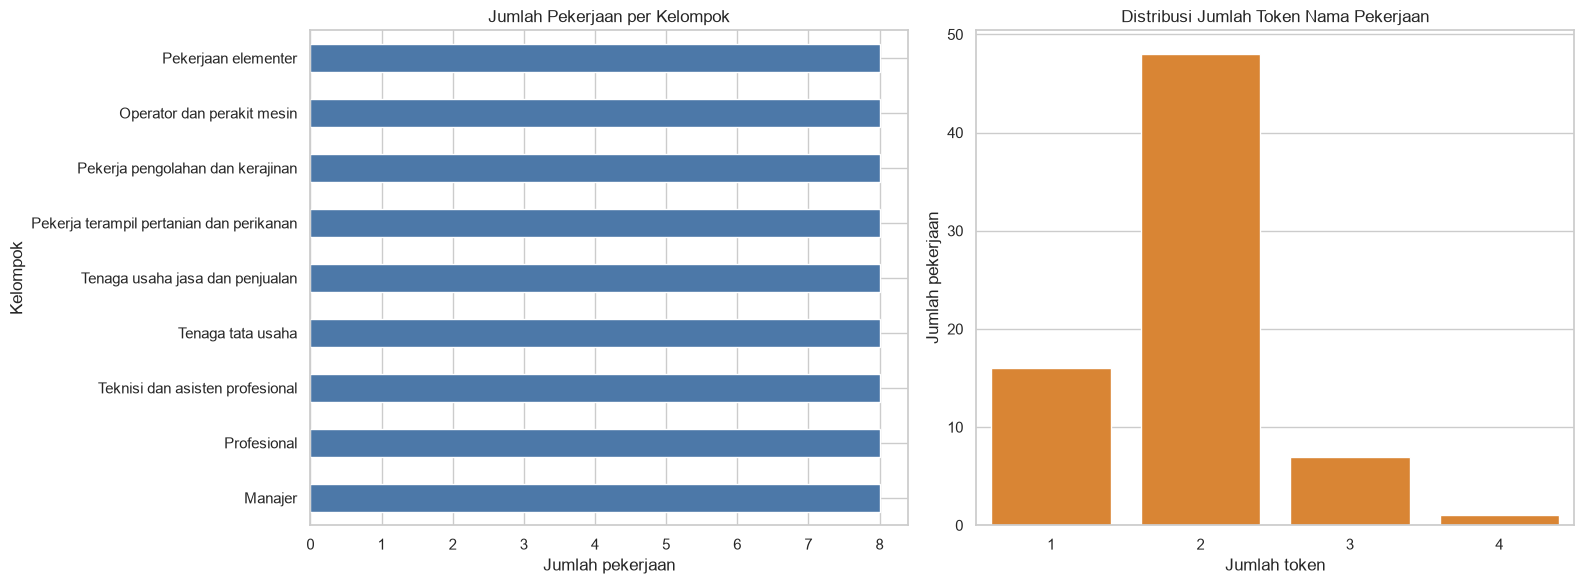

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_pekerjaan["major_group_name"].value_counts().sort_values().plot.barh(ax=axes[0], color="#4C78A8")
axes[0].set(title="Jumlah Pekerjaan per Kelompok", xlabel="Jumlah pekerjaan", ylabel="Kelompok")
sns.countplot(data=df_pekerjaan, x="token_count", ax=axes[1], color="#F58518")
axes[1].set(title="Distribusi Jumlah Token Nama Pekerjaan", xlabel="Jumlah token", ylabel="Jumlah pekerjaan")
fig.tight_layout()
display(fig)
plt.close(fig)

## 4. Pembuatan istilah gender

In [5]:
gender_pairs_input = [
    ("G01", "laki-laki", "perempuan", "identitas umum"),
    ("G02", "pria", "wanita", "identitas umum"),
    ("G03", "ayah", "ibu", "kekerabatan"),
    ("G04", "suami", "istri", "perkawinan"),
    ("G05", "putra", "putri", "kekerabatan"),
    ("G06", "pemuda", "pemudi", "usia atau generasi"),
    ("G07", "cowok", "cewek", "informal"),
    ("G08", "jejaka", "gadis", "usia atau generasi"),
]

gender_rows = []
for pair_id, male, female, category in gender_pairs_input:
    gender_rows.extend([
        {"term_id": f"{pair_id}_M", "term": male, "gender_group": "laki-laki", "lexical_category": category, "pair_id": pair_id},
        {"term_id": f"{pair_id}_F", "term": female, "gender_group": "perempuan", "lexical_category": category, "pair_id": pair_id},
    ])

df_istilah_gender = pd.DataFrame(gender_rows)
df_istilah_gender.to_csv(DATA_DIR / f"{OUTPUT_PREFIX}istilah_gender.csv", index=False)
display(df_istilah_gender)
display(df_istilah_gender["gender_group"].value_counts().rename("term_count").to_frame())
display(df_istilah_gender["lexical_category"].value_counts().rename("term_count").to_frame())

,term_id,term,gender_group,lexical_category,pair_id
0,G01_M,laki-laki,laki-laki,identitas umum,G01
1,G01_F,perempuan,perempuan,identitas umum,G01
2,G02_M,pria,laki-laki,identitas umum,G02
3,G02_F,wanita,perempuan,identitas umum,G02
4,G03_M,ayah,laki-laki,kekerabatan,G03
5,G03_F,ibu,perempuan,kekerabatan,G03
6,G04_M,suami,laki-laki,perkawinan,G04
7,G04_F,istri,perempuan,perkawinan,G04
8,G05_M,putra,laki-laki,kekerabatan,G05
9,G05_F,putri,perempuan,kekerabatan,G05


,term_count
gender_group,
laki-laki,8
perempuan,8


,term_count
lexical_category,
identitas umum,4
kekerabatan,4
usia atau generasi,4
perkawinan,2
informal,2


In [6]:
pair_completeness = df_istilah_gender.groupby("pair_id")["gender_group"].nunique().rename("gender_group_count").to_frame()
duplicate_terms = df_istilah_gender[df_istilah_gender["term"].duplicated(keep=False)]
print("Pasangan tidak lengkap:")
display(pair_completeness[pair_completeness["gender_group_count"] != 2])
print("Duplikasi istilah:")
display(duplicate_terms)

Pasangan tidak lengkap:


,gender_group_count
pair_id,


Duplikasi istilah:


,term_id,term,gender_group,lexical_category,pair_id


## 5. Pembentukan ruang embedding yang terkendali

Generator menggunakan seed deterministik berbasis identitas objek. Dengan demikian, vektor suatu token, kelompok, atau pekerjaan tidak ditentukan oleh posisi baris. Pusat kelompok dan komponen token diproyeksikan tegak lurus terhadap sumbu gender. Satu-satunya komponen pekerjaan yang sengaja sejajar dengan sumbu gender adalah `latent_gender_signal`.

In [7]:
def stable_rng(label):
    digest = hashlib.sha256(f"{RANDOM_SEED}|{label}".encode("utf-8")).digest()
    return np.random.default_rng(int.from_bytes(digest[:8], "little"))


def get_phrase_vector(text, token_vectors):
    tokens = str(text).lower().split()
    return np.mean([token_vectors[token] for token in tokens], axis=0)


def calculate_sc_weat(occupation_vector, male_vectors, female_vectors):
    male_similarity = cosine_similarity(occupation_vector.reshape(1, -1), male_vectors).ravel()
    female_similarity = cosine_similarity(occupation_vector.reshape(1, -1), female_vectors).ravel()
    all_similarity = np.concatenate([male_similarity, female_similarity])
    association_difference = float(male_similarity.mean() - female_similarity.mean())
    standard_deviation = float(np.std(all_similarity, ddof=1))
    effect_size = np.nan if standard_deviation == 0 or not np.isfinite(standard_deviation) else association_difference / standard_deviation
    return {
        "mean_male_similarity": float(male_similarity.mean()),
        "mean_female_similarity": float(female_similarity.mean()),
        "association_difference": association_difference,
        "similarity_standard_deviation": standard_deviation,
        "scweat_effect_size": effect_size,
    }


gender_axis = stable_rng("gender_axis").normal(size=EMBEDDING_DIM)
gender_axis = gender_axis / np.linalg.norm(gender_axis)

group_centers = {}
for group_name, _ in occupation_groups.values():
    vector = stable_rng(f"group::{group_name}").normal(size=EMBEDDING_DIM)
    vector = vector - np.dot(vector, gender_axis) * gender_axis
    group_centers[group_name] = vector / np.linalg.norm(vector)

all_occupation_tokens = sorted({token for name in df_pekerjaan["occupation_name"] for token in name.lower().split()})
token_vectors = {}
for token in all_occupation_tokens:
    vector = stable_rng(f"token::{token}").normal(size=EMBEDDING_DIM)
    vector = vector - np.dot(vector, gender_axis) * gender_axis
    token_vectors[token] = vector / np.linalg.norm(vector)

gender_term_vectors = {}
for pair_id, male_term, female_term, _ in gender_pairs_input:
    pair_context = stable_rng(f"pair::{pair_id}").normal(size=EMBEDDING_DIM)
    pair_context = pair_context - np.dot(pair_context, gender_axis) * gender_axis
    pair_context = pair_context / np.linalg.norm(pair_context)

    male_variation = stable_rng(f"term::{male_term}").normal(size=EMBEDDING_DIM)
    male_variation = male_variation - np.dot(male_variation, gender_axis) * gender_axis
    male_variation = male_variation / np.linalg.norm(male_variation)

    female_variation = stable_rng(f"term::{female_term}").normal(size=EMBEDDING_DIM)
    female_variation = female_variation - np.dot(female_variation, gender_axis) * gender_axis
    female_variation = female_variation / np.linalg.norm(female_variation)

    male_vector = 1.40 * gender_axis + 1.30 * pair_context + 0.10 * male_variation
    female_vector = -1.40 * gender_axis + 1.30 * pair_context + 0.10 * female_variation
    gender_term_vectors[male_term] = male_vector / np.linalg.norm(male_vector)
    gender_term_vectors[female_term] = female_vector / np.linalg.norm(female_vector)

latent_values = np.linspace(-0.45, 0.45, len(df_pekerjaan))
latent_values = latent_values[stable_rng("latent_assignment").permutation(len(latent_values))]
latent_signal_map = dict(zip(sorted(df_pekerjaan["occupation_id"]), latent_values))

occupation_vectors_by_id = {}
for row in df_pekerjaan.itertuples(index=False):
    lexical_vector = get_phrase_vector(row.occupation_name, token_vectors)
    lexical_vector = lexical_vector / np.linalg.norm(lexical_vector)
    occupation_noise = stable_rng(f"occupation::{row.occupation_id}").normal(size=EMBEDDING_DIM)
    occupation_noise = occupation_noise - np.dot(occupation_noise, gender_axis) * gender_axis
    occupation_noise = occupation_noise / np.linalg.norm(occupation_noise)
    raw_vector = (
        1.10 * group_centers[row.major_group_name]
        + 0.30 * lexical_vector
        + latent_signal_map[row.occupation_id] * gender_axis
        + 0.04 * occupation_noise
    )
    occupation_vectors_by_id[row.occupation_id] = raw_vector / np.linalg.norm(raw_vector)

occupation_vectors = np.vstack([occupation_vectors_by_id[occupation_id] for occupation_id in df_pekerjaan["occupation_id"]])
term_vectors = np.vstack([gender_term_vectors[term] for term in df_istilah_gender["term"]])

df_pekerjaan["latent_gender_signal"] = df_pekerjaan["occupation_id"].map(latent_signal_map)
display(df_pekerjaan.head(10))

,occupation_id,occupation_name,major_group_code,major_group_name,token_count,latent_gender_signal
0,101,direktur utama,1,Manajer,2,0.133099
1,102,manajer operasional,1,Manajer,2,-0.437324
2,103,manajer keuangan,1,Manajer,2,0.437324
3,104,manajer pemasaran,1,Manajer,2,-0.361268
4,105,kepala cabang,1,Manajer,2,0.386620
5,106,supervisor produksi,1,Manajer,2,-0.450000
6,107,koordinator proyek,1,Manajer,2,-0.031690
7,108,manajer sumber daya manusia,1,Manajer,4,0.361268
8,201,dokter,2,Profesional,1,0.006338
9,202,perawat,2,Profesional,1,0.095070


### Audit komponen generator

In [8]:
token_usage = pd.Series([token for name in df_pekerjaan["occupation_name"] for token in name.lower().split()]).value_counts().rename_axis("token").reset_index(name="occupation_name_count")
shared_token_audit = token_usage[token_usage["occupation_name_count"] > 1].copy()
shared_token_audit["absolute_gender_projection"] = shared_token_audit["token"].map(lambda token: abs(float(np.dot(token_vectors[token], gender_axis))))

group_center_audit = pd.DataFrame({
    "major_group_name": list(group_centers),
    "gender_axis_projection": [float(np.dot(group_centers[name], gender_axis)) for name in group_centers],
    "center_norm": [float(np.linalg.norm(group_centers[name])) for name in group_centers],
})

vector_audit = pd.DataFrame({
    "object": ["occupation_vectors", "gender_term_vectors", "gender_axis"],
    "row_count": [occupation_vectors.shape[0], term_vectors.shape[0], 1],
    "dimension": [occupation_vectors.shape[1], term_vectors.shape[1], len(gender_axis)],
    "minimum_norm": [np.linalg.norm(occupation_vectors, axis=1).min(), np.linalg.norm(term_vectors, axis=1).min(), np.linalg.norm(gender_axis)],
    "maximum_norm": [np.linalg.norm(occupation_vectors, axis=1).max(), np.linalg.norm(term_vectors, axis=1).max(), np.linalg.norm(gender_axis)],
})

print("Jumlah token pekerjaan unik:", len(token_vectors))
print("Jumlah token yang muncul pada lebih dari satu nama pekerjaan:", len(shared_token_audit))
print("Shape matriks embedding pekerjaan:", occupation_vectors.shape)
print("NaN:", bool(np.isnan(occupation_vectors).any()), "Infinity:", bool(np.isinf(occupation_vectors).any()))
display(pd.DataFrame(occupation_vectors[:5, :5], index=df_pekerjaan["occupation_name"].head(5), columns=[f"dim_{i}" for i in range(1, 6)]).round(4))
display(vector_audit.round(12))
display(group_center_audit.round(12))
display(shared_token_audit)

Jumlah token pekerjaan unik: 114
Jumlah token yang muncul pada lebih dari satu nama pekerjaan: 14
Shape matriks embedding pekerjaan: (72, 300)
NaN: False Infinity: False


,dim_1,dim_2,dim_3,dim_4,dim_5
occupation_name,,,,,
direktur utama,0.0781,0.0142,-0.0677,0.0693,-0.0420
manajer operasional,0.0588,-0.0270,-0.0158,0.1006,-0.0234
manajer keuangan,0.0555,0.0290,-0.0709,0.0731,-0.0272
manajer pemasaran,0.0355,-0.0213,-0.0328,0.0798,-0.0145
kepala cabang,0.0442,0.0167,-0.0733,0.0572,-0.0369


,object,row_count,dimension,minimum_norm,maximum_norm
0,occupation_vectors,72,300,1.0,1.0
1,gender_term_vectors,16,300,1.0,1.0
2,gender_axis,1,300,1.0,1.0


,major_group_name,gender_axis_projection,center_norm
0,Manajer,0.0,1.0
1,Profesional,-0.0,1.0
2,Teknisi dan asisten profesional,-0.0,1.0
3,Tenaga tata usaha,0.0,1.0
4,Tenaga usaha jasa dan penjualan,-0.0,1.0
5,Pekerja terampil pertanian dan perikanan,-0.0,1.0
6,Pekerja pengolahan dan kerajinan,-0.0,1.0
7,Operator dan perakit mesin,0.0,1.0
8,Pekerjaan elementer,-0.0,1.0


,token,occupation_name_count,absolute_gender_projection
0,operator,5,1.143833e-17
1,manajer,4,2.406929e-17
2,petugas,4,7.264155e-18
3,pekerja,3,4.119968e-18
4,tukang,3,2.059984e-17
5,data,2,4.878910e-18
6,staf,2,1.187201e-17
7,teknisi,2,1.517883e-18
8,analis,2,8.890458e-18
9,sekretaris,2,1.745565e-17


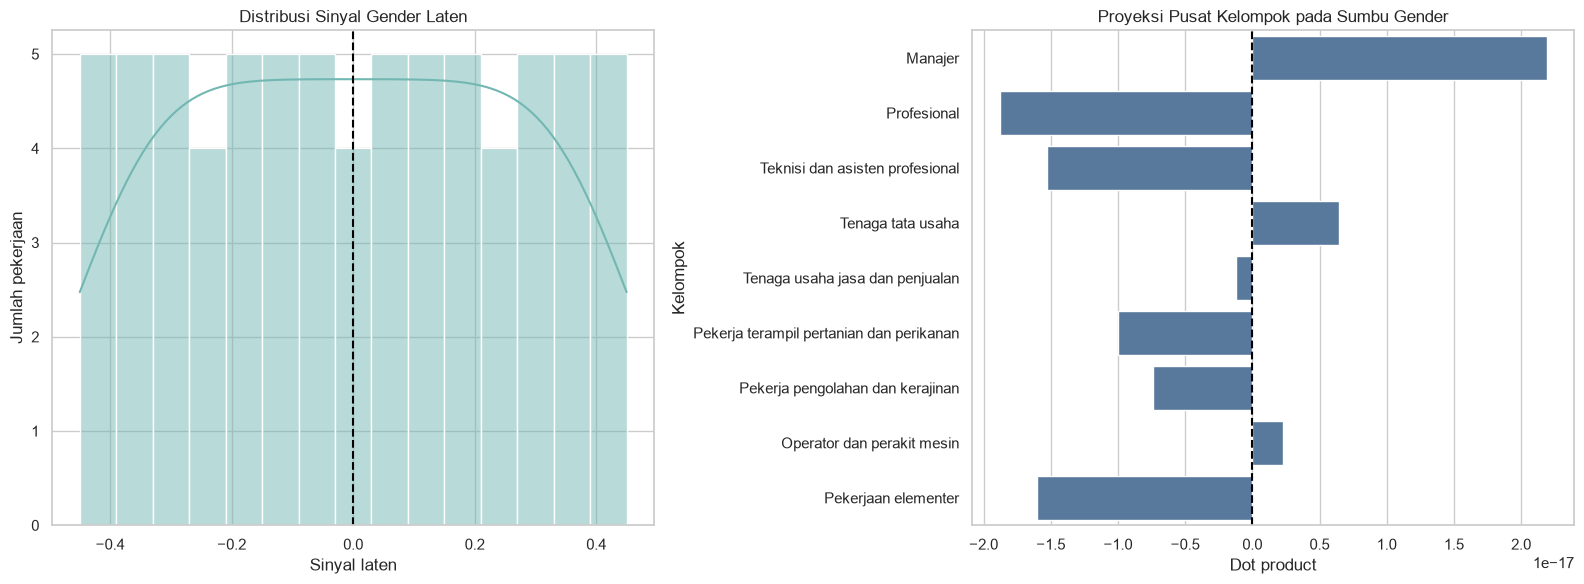

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df_pekerjaan["latent_gender_signal"], bins=15, kde=True, color="#72B7B2", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set(title="Distribusi Sinyal Gender Laten", xlabel="Sinyal laten", ylabel="Jumlah pekerjaan")
sns.barplot(data=group_center_audit, x="gender_axis_projection", y="major_group_name", color="#4C78A8", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Proyeksi Pusat Kelompok pada Sumbu Gender", xlabel="Dot product", ylabel="Kelompok")
fig.tight_layout()
display(fig)
plt.close(fig)

## 6. Visualisasi ruang embedding dengan PCA

In [10]:
pca_input = np.vstack([term_vectors, occupation_vectors])
pca_model = PCA(n_components=2, random_state=RANDOM_SEED)
pca_coordinates = pca_model.fit_transform(pca_input)

term_coordinates = pd.DataFrame(pca_coordinates[:len(df_istilah_gender)], columns=["PC1", "PC2"])
term_coordinates = pd.concat([df_istilah_gender.reset_index(drop=True), term_coordinates], axis=1)
occupation_coordinates = pd.DataFrame(pca_coordinates[len(df_istilah_gender):], columns=["PC1", "PC2"])
occupation_coordinates = pd.concat([df_pekerjaan.reset_index(drop=True), occupation_coordinates], axis=1)

display(pd.DataFrame({
    "component": ["PC1", "PC2", "total"],
    "explained_variance_ratio": [pca_model.explained_variance_ratio_[0], pca_model.explained_variance_ratio_[1], pca_model.explained_variance_ratio_.sum()],
}).round(4))

,component,explained_variance_ratio
0,PC1,0.1555
1,PC2,0.1085
2,total,0.2640


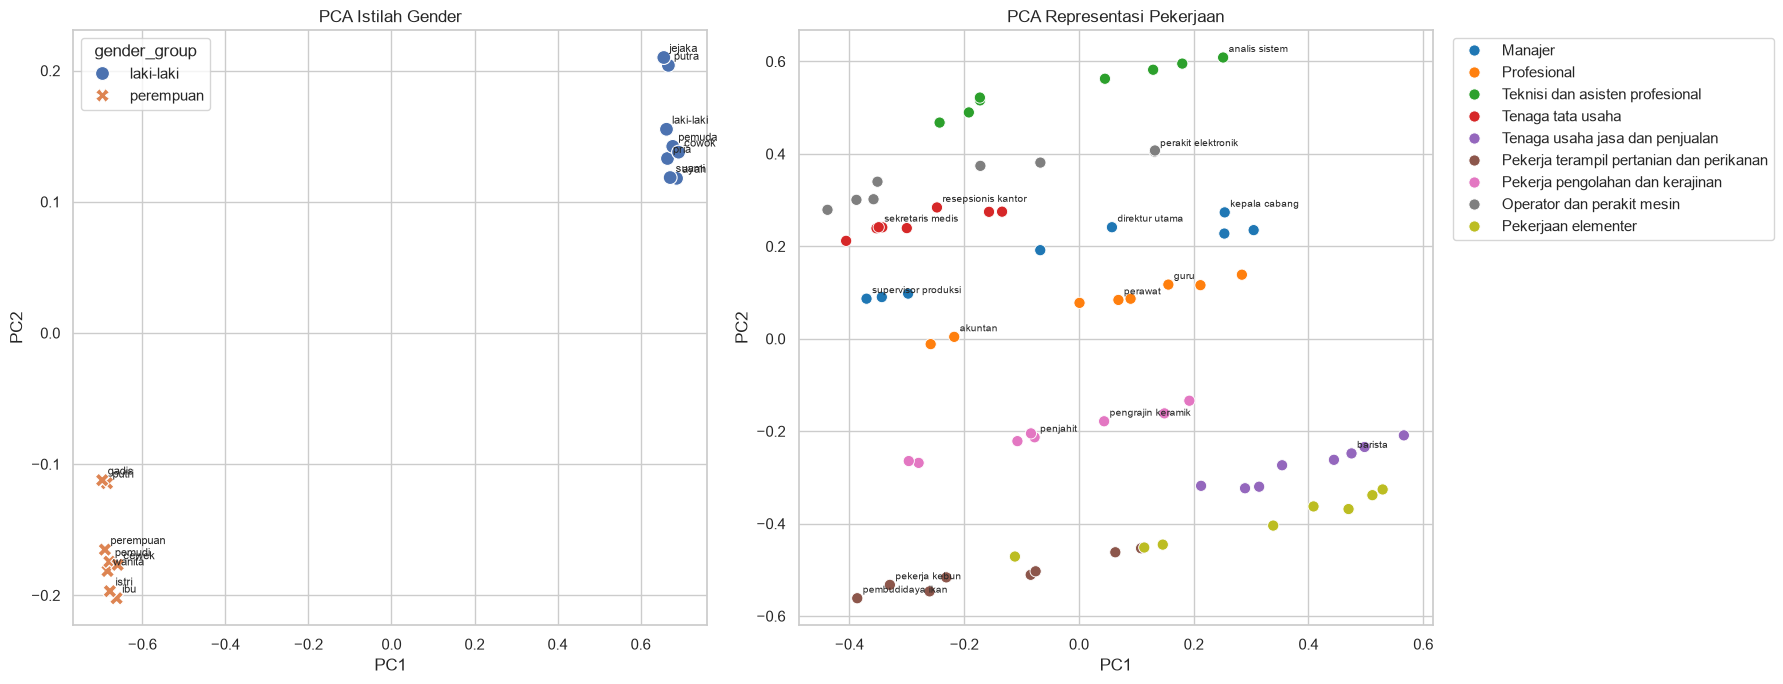

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=term_coordinates, x="PC1", y="PC2", hue="gender_group", style="gender_group", s=100, ax=axes[0])
for _, row in term_coordinates.iterrows():
    axes[0].annotate(row["term"], (row["PC1"], row["PC2"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[0].set(title="PCA Istilah Gender", xlabel="PC1", ylabel="PC2")

sns.scatterplot(data=occupation_coordinates, x="PC1", y="PC2", hue="major_group_name", palette="tab10", s=65, ax=axes[1])
for _, row in occupation_coordinates.sample(15, random_state=RANDOM_SEED).iterrows():
    axes[1].annotate(row["occupation_name"], (row["PC1"], row["PC2"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
axes[1].set(title="PCA Representasi Pekerjaan", xlabel="PC1", ylabel="PC2")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)

## 7. Cosine similarity pekerjaan dan istilah gender

In [12]:
male_mask = df_istilah_gender["gender_group"].eq("laki-laki").to_numpy()
female_mask = df_istilah_gender["gender_group"].eq("perempuan").to_numpy()
male_vectors = term_vectors[male_mask]
female_vectors = term_vectors[female_mask]
male_terms = df_istilah_gender.loc[male_mask, "term"].tolist()
female_terms = df_istilah_gender.loc[female_mask, "term"].tolist()

male_similarity_matrix = cosine_similarity(occupation_vectors, male_vectors)
female_similarity_matrix = cosine_similarity(occupation_vectors, female_vectors)
all_gender_similarity = np.hstack([male_similarity_matrix, female_similarity_matrix])

similarity_results = df_pekerjaan[["occupation_id", "occupation_name", "major_group_name", "latent_gender_signal"]].copy()
similarity_results["mean_male_similarity"] = male_similarity_matrix.mean(axis=1)
similarity_results["mean_female_similarity"] = female_similarity_matrix.mean(axis=1)
similarity_results["similarity_difference"] = similarity_results["mean_male_similarity"] - similarity_results["mean_female_similarity"]
display(similarity_results.head(10).round(4))
display(similarity_results.nlargest(TOP_N, "mean_male_similarity").round(4))
display(similarity_results.nlargest(TOP_N, "mean_female_similarity").round(4))

,occupation_id,occupation_name,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,similarity_difference
0,101,direktur utama,Manajer,0.1331,0.0980,-0.0668,0.1648
1,102,manajer operasional,Manajer,-0.4373,-0.2368,0.2732,-0.5100
2,103,manajer keuangan,Manajer,0.4373,0.2794,-0.2346,0.5140
3,104,manajer pemasaran,Manajer,-0.3613,-0.1927,0.2407,-0.4334
4,105,kepala cabang,Manajer,0.3866,0.2496,-0.2117,0.4614
5,106,supervisor produksi,Manajer,-0.4500,-0.2448,0.2877,-0.5325
6,107,koordinator proyek,Manajer,-0.0317,-0.0017,0.0425,-0.0442
7,108,manajer sumber daya manusia,Manajer,0.3613,0.2361,-0.2015,0.4376
8,201,dokter,Profesional,0.0063,0.0221,0.0148,0.0073
9,202,perawat,Profesional,0.0951,0.0807,-0.0417,0.1224


,occupation_id,occupation_name,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,similarity_difference
2,103,manajer keuangan,Manajer,0.4373,0.2794,-0.2346,0.5140
70,907,pekerja bongkar muat,Pekerjaan elementer,0.4500,0.2699,-0.2634,0.5333
14,207,psikolog,Profesional,0.3739,0.2528,-0.2048,0.4575
64,901,petugas kebersihan,Pekerjaan elementer,0.3993,0.2518,-0.2524,0.5042
35,504,penata rambut,Tenaga usaha jasa dan penjualan,0.4246,0.2518,-0.2742,0.5260
4,105,kepala cabang,Manajer,0.3866,0.2496,-0.2117,0.4614
7,108,manajer sumber daya manusia,Manajer,0.3613,0.2361,-0.2015,0.4376
18,303,analis sistem,Teknisi dan asisten profesional,0.4120,0.2234,-0.2616,0.4850
68,905,pemulung,Pekerjaan elementer,0.3359,0.2164,-0.2003,0.4168
32,501,kasir,Tenaga usaha jasa dan penjualan,0.3486,0.2029,-0.2148,0.4177


,occupation_id,occupation_name,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,similarity_difference
5,106,supervisor produksi,Manajer,-0.4500,-0.2448,0.2877,-0.5325
1,102,manajer operasional,Manajer,-0.4373,-0.2368,0.2732,-0.5100
59,804,pengemudi bus,Operator dan perakit mesin,-0.4120,-0.2532,0.2522,-0.5054
45,606,pembudidaya ikan,Pekerja terampil pertanian dan perikanan,-0.4246,-0.2556,0.2491,-0.5047
65,902,pekerja rumah tangga,Pekerjaan elementer,-0.3993,-0.2358,0.2412,-0.4771
3,104,manajer pemasaran,Manajer,-0.3613,-0.1927,0.2407,-0.4334
15,208,arsitek,Profesional,-0.3232,-0.1733,0.2369,-0.4102
61,806,operator pabrik,Operator dan perakit mesin,-0.3486,-0.2181,0.2077,-0.4258
53,706,tukang las,Pekerja pengolahan dan kerajinan,-0.3866,-0.2705,0.2053,-0.4758
47,608,pekerja kebun,Pekerja terampil pertanian dan perikanan,-0.3359,-0.2084,0.2049,-0.4133


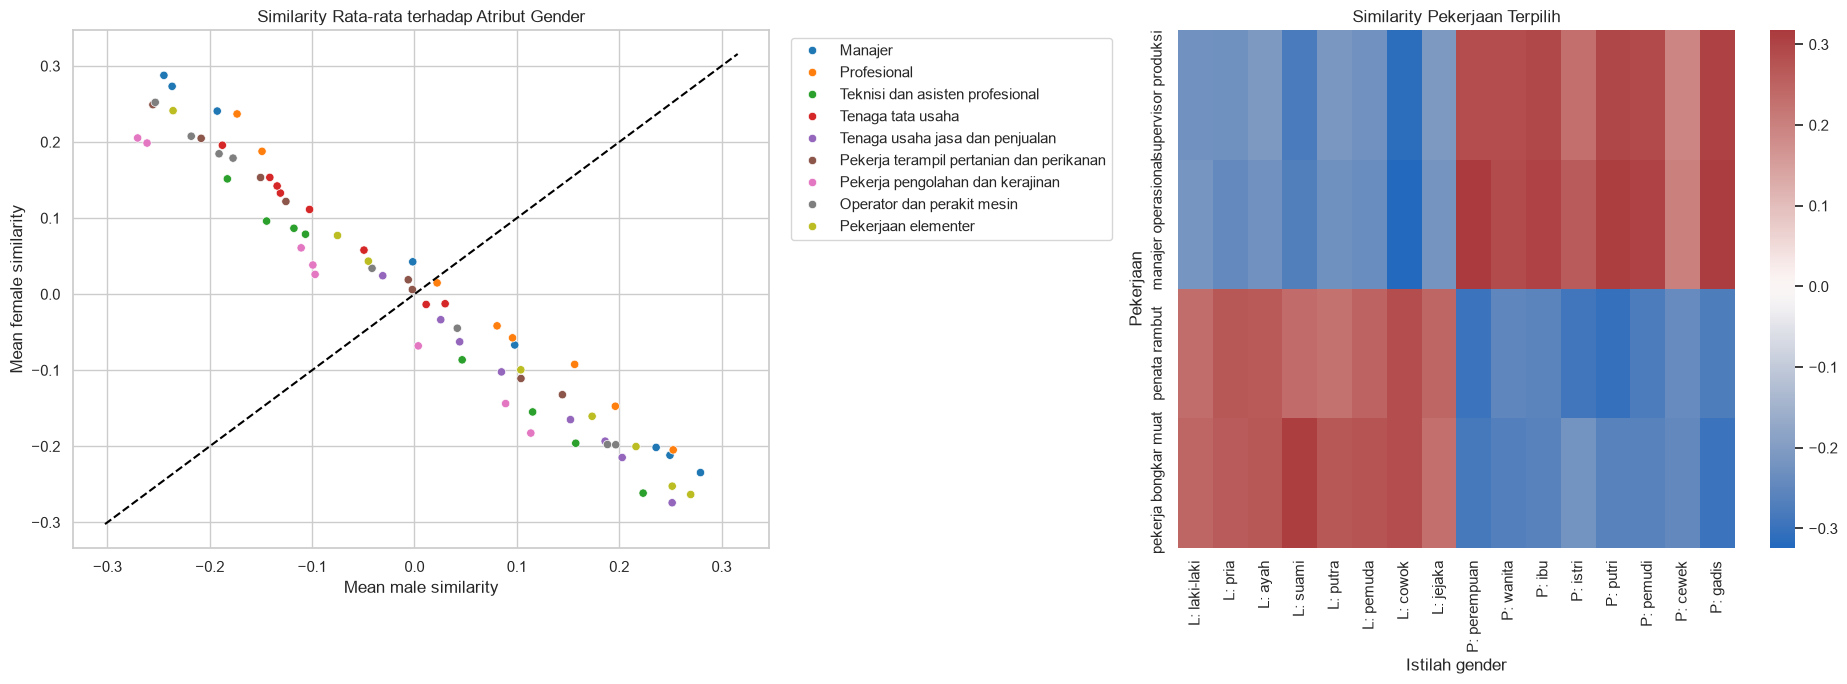

In [13]:
selected_occupations = similarity_results.sort_values("similarity_difference").iloc[[0, 1, -2, -1]]["occupation_name"].tolist()
selected_indices = df_pekerjaan.index[df_pekerjaan["occupation_name"].isin(selected_occupations)].tolist()
heatmap_columns = [f"L: {term}" for term in male_terms] + [f"P: {term}" for term in female_terms]

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.scatterplot(data=similarity_results, x="mean_male_similarity", y="mean_female_similarity", hue="major_group_name", palette="tab10", ax=axes[0])
lower = min(axes[0].get_xlim()[0], axes[0].get_ylim()[0])
upper = max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
axes[0].plot([lower, upper], [lower, upper], linestyle="--", color="black")
axes[0].set(title="Similarity Rata-rata terhadap Atribut Gender", xlabel="Mean male similarity", ylabel="Mean female similarity")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

sns.heatmap(pd.DataFrame(all_gender_similarity[selected_indices], index=selected_occupations, columns=heatmap_columns), cmap="vlag", center=0, ax=axes[1])
axes[1].set(title="Similarity Pekerjaan Terpilih", xlabel="Istilah gender", ylabel="Pekerjaan")
fig.tight_layout()
display(fig)
plt.close(fig)

## 8. Perhitungan SC-WEAT

Orientasi skor ditetapkan sebagai berikut: nilai positif menunjukkan asosiasi relatif lebih dekat terhadap atribut laki-laki, sedangkan nilai negatif menunjukkan asosiasi relatif lebih dekat terhadap atribut perempuan. Standar deviasi sampel (`ddof=1`) digunakan secara konsisten pada gabungan similarity terhadap 16 atribut.

In [14]:
scweat_rows = []
for row, vector in zip(df_pekerjaan.itertuples(index=False), occupation_vectors):
    scores = calculate_sc_weat(vector, male_vectors, female_vectors)
    effect = scores["scweat_effect_size"]
    scweat_rows.append({
        "occupation_id": row.occupation_id,
        "occupation_name": row.occupation_name,
        "major_group_code": row.major_group_code,
        "major_group_name": row.major_group_name,
        "latent_gender_signal": row.latent_gender_signal,
        **scores,
        "association_direction": "positif" if effect > 0 else "negatif" if effect < 0 else "mendekati nol",
    })

scweat_results = pd.DataFrame(scweat_rows)
display(scweat_results.head(10).round(4))

,occupation_id,occupation_name,major_group_code,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,association_difference,similarity_standard_deviation,scweat_effect_size,association_direction
0,101,direktur utama,1,Manajer,0.1331,0.0980,-0.0668,0.1648,0.0951,1.7325,positif
1,102,manajer operasional,1,Manajer,-0.4373,-0.2368,0.2732,-0.5100,0.2661,-1.9168,negatif
2,103,manajer keuangan,1,Manajer,0.4373,0.2794,-0.2346,0.5140,0.2689,1.9112,positif
3,104,manajer pemasaran,1,Manajer,-0.3613,-0.1927,0.2407,-0.4334,0.2283,-1.8982,negatif
4,105,kepala cabang,1,Manajer,0.3866,0.2496,-0.2117,0.4614,0.2413,1.9122,positif
5,106,supervisor produksi,1,Manajer,-0.4500,-0.2448,0.2877,-0.5325,0.2773,-1.9199,negatif
6,107,koordinator proyek,1,Manajer,-0.0317,-0.0017,0.0425,-0.0442,0.0503,-0.8784,negatif
7,108,manajer sumber daya manusia,1,Manajer,0.3613,0.2361,-0.2015,0.4376,0.2292,1.9093,positif
8,201,dokter,2,Profesional,0.0063,0.0221,0.0148,0.0073,0.0473,0.1541,positif
9,202,perawat,2,Profesional,0.0951,0.0807,-0.0417,0.1224,0.0784,1.5600,positif


## 9. Pemulihan sinyal laten

In [15]:
latent_pearson = pearsonr(scweat_results["latent_gender_signal"], scweat_results["scweat_effect_size"])
latent_spearman = spearmanr(scweat_results["latent_gender_signal"], scweat_results["scweat_effect_size"])
latent_direction_agreement = np.mean(np.sign(scweat_results["latent_gender_signal"]) == np.sign(scweat_results["scweat_effect_size"]))

latent_recovery = pd.DataFrame({
    "metric": ["Pearson correlation", "Spearman rank correlation", "direction agreement"],
    "value": [latent_pearson.statistic, latent_spearman.statistic, latent_direction_agreement],
    "p_value": [latent_pearson.pvalue, latent_spearman.pvalue, np.nan],
})
display(latent_recovery.round(6))
display(scweat_results[["occupation_id", "occupation_name", "latent_gender_signal", "scweat_effect_size", "association_direction"]].sort_values("latent_gender_signal").head(10).round(4))

,metric,value,p_value
0,Pearson correlation,0.916206,0.0
1,Spearman rank correlation,0.979549,0.0
2,direction agreement,1.000000,NaN


,occupation_id,occupation_name,latent_gender_signal,scweat_effect_size,association_direction
5,106,supervisor produksi,-0.4500,-1.9199,negatif
1,102,manajer operasional,-0.4373,-1.9168,negatif
45,606,pembudidaya ikan,-0.4246,-1.9305,negatif
59,804,pengemudi bus,-0.4120,-1.9176,negatif
65,902,pekerja rumah tangga,-0.3993,-1.9260,negatif
53,706,tukang las,-0.3866,-1.9194,negatif
49,702,tukang batu,-0.3739,-1.9203,negatif
3,104,manajer pemasaran,-0.3613,-1.8982,negatif
61,806,operator pabrik,-0.3486,-1.9159,negatif
47,608,pekerja kebun,-0.3359,-1.9302,negatif


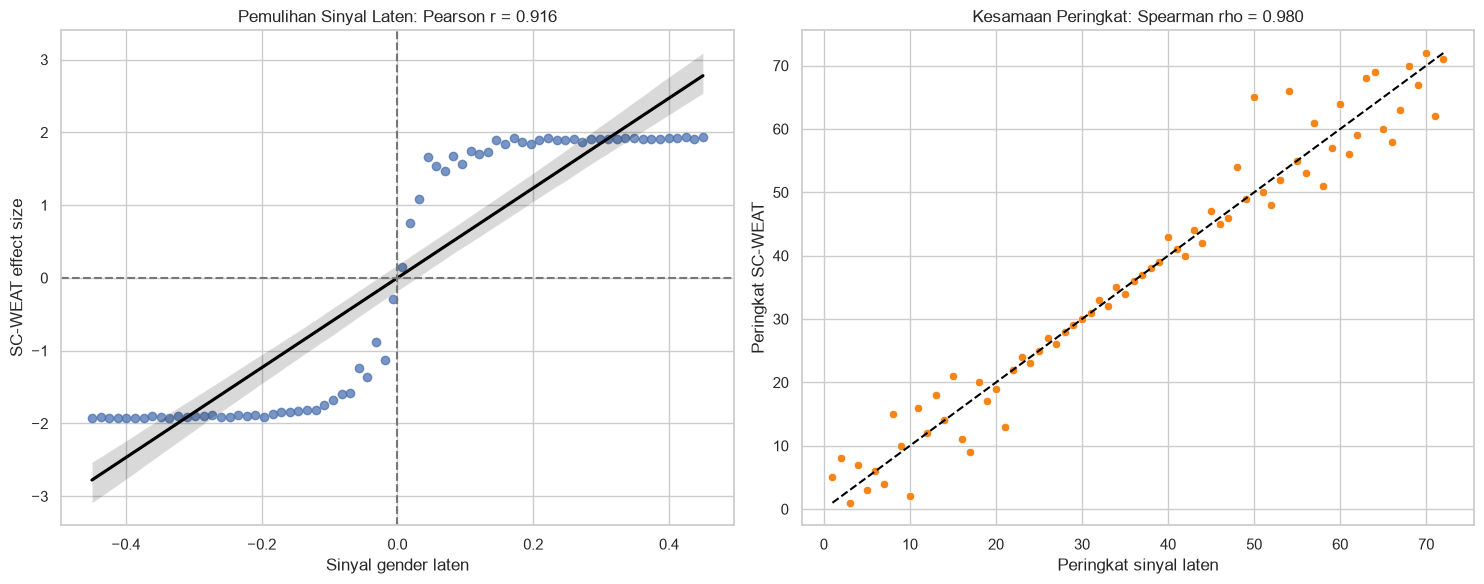

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.regplot(data=scweat_results, x="latent_gender_signal", y="scweat_effect_size", scatter_kws={"alpha": 0.75}, line_kws={"color": "black"}, ax=axes[0])
axes[0].axhline(0, color="#777777", linestyle="--")
axes[0].axvline(0, color="#777777", linestyle="--")
axes[0].set(title=f"Pemulihan Sinyal Laten: Pearson r = {latent_pearson.statistic:.3f}", xlabel="Sinyal gender laten", ylabel="SC-WEAT effect size")

rank_comparison = scweat_results[["latent_gender_signal", "scweat_effect_size"]].rank().rename(columns={"latent_gender_signal": "latent_rank", "scweat_effect_size": "scweat_rank"})
sns.scatterplot(data=rank_comparison, x="latent_rank", y="scweat_rank", color="#F58518", ax=axes[1])
axes[1].plot([1, len(rank_comparison)], [1, len(rank_comparison)], color="black", linestyle="--")
axes[1].set(title=f"Kesamaan Peringkat: Spearman rho = {latent_spearman.statistic:.3f}", xlabel="Peringkat sinyal laten", ylabel="Peringkat SC-WEAT")
fig.tight_layout()
display(fig)
plt.close(fig)

## 10. Exact permutation test dan koreksi FDR

Gabungan 16 atribut dibagi ke seluruh kemungkinan kelompok berukuran 8 dan 8. Jumlah pembagian yang diuji adalah $\binom{16}{8}=12.870$. P-value dua sisi dihitung dari proporsi statistik permutasi yang nilai absolutnya sekurang-kurangnya sebesar statistik observasi.

In [17]:
combination_indices = np.array(list(combinations(range(len(male_terms) + len(female_terms)), len(male_terms))), dtype=int)
exact_partition_count = len(combination_indices)
permutation_rows = []

for row_index, row in scweat_results.iterrows():
    observed = float(row["association_difference"])
    observed_similarity = all_gender_similarity[row_index]
    selected_sums = observed_similarity[combination_indices].sum(axis=1)
    null_statistics = selected_sums / len(male_terms) - (observed_similarity.sum() - selected_sums) / len(female_terms)
    p_value = np.count_nonzero(np.abs(null_statistics) >= abs(observed) - 1e-15) / exact_partition_count
    permutation_rows.append({
        "occupation_id": row["occupation_id"],
        "p_value": p_value,
        "exact_partition_count": exact_partition_count,
        "test_sidedness": "two-sided",
    })

permutation_results = pd.DataFrame(permutation_rows)
reject_fdr, adjusted_p_values, _, _ = multipletests(permutation_results["p_value"], alpha=ALPHA, method="fdr_bh")
permutation_results["adjusted_p_value"] = adjusted_p_values
permutation_results["significant_raw"] = permutation_results["p_value"] < ALPHA
permutation_results["significant_fdr"] = reject_fdr
scweat_results = scweat_results.merge(permutation_results, on="occupation_id", validate="one_to_one")

print("Jumlah pembagian exact:", exact_partition_count)
print("Signifikan sebelum koreksi:", int(permutation_results["significant_raw"].sum()))
print("Signifikan setelah FDR:", int(permutation_results["significant_fdr"].sum()))
display(scweat_results.nsmallest(TOP_N, "adjusted_p_value").round(4))

Jumlah pembagian exact: 12870
Signifikan sebelum koreksi: 68
Signifikan setelah FDR: 68


,occupation_id,occupation_name,major_group_code,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,association_difference,similarity_standard_deviation,scweat_effect_size,association_direction,p_value,exact_partition_count,test_sidedness,adjusted_p_value,significant_raw,significant_fdr
0,101,direktur utama,1,Manajer,0.1331,0.0980,-0.0668,0.1648,0.0951,1.7325,positif,0.0002,12870,two-sided,0.0002,True,True
1,102,manajer operasional,1,Manajer,-0.4373,-0.2368,0.2732,-0.5100,0.2661,-1.9168,negatif,0.0002,12870,two-sided,0.0002,True,True
2,103,manajer keuangan,1,Manajer,0.4373,0.2794,-0.2346,0.5140,0.2689,1.9112,positif,0.0002,12870,two-sided,0.0002,True,True
3,104,manajer pemasaran,1,Manajer,-0.3613,-0.1927,0.2407,-0.4334,0.2283,-1.8982,negatif,0.0002,12870,two-sided,0.0002,True,True
4,105,kepala cabang,1,Manajer,0.3866,0.2496,-0.2117,0.4614,0.2413,1.9122,positif,0.0002,12870,two-sided,0.0002,True,True
5,106,supervisor produksi,1,Manajer,-0.4500,-0.2448,0.2877,-0.5325,0.2773,-1.9199,negatif,0.0002,12870,two-sided,0.0002,True,True
7,108,manajer sumber daya manusia,1,Manajer,0.3613,0.2361,-0.2015,0.4376,0.2292,1.9093,positif,0.0002,12870,two-sided,0.0002,True,True
10,203,guru,2,Profesional,0.1965,0.1565,-0.0923,0.2488,0.1355,1.8371,positif,0.0002,12870,two-sided,0.0002,True,True
11,204,dosen,2,Profesional,0.2725,0.1962,-0.1473,0.3436,0.1837,1.8708,positif,0.0002,12870,two-sided,0.0002,True,True
12,205,akuntan,2,Profesional,-0.2725,-0.1489,0.1878,-0.3367,0.1793,-1.8783,negatif,0.0002,12870,two-sided,0.0002,True,True


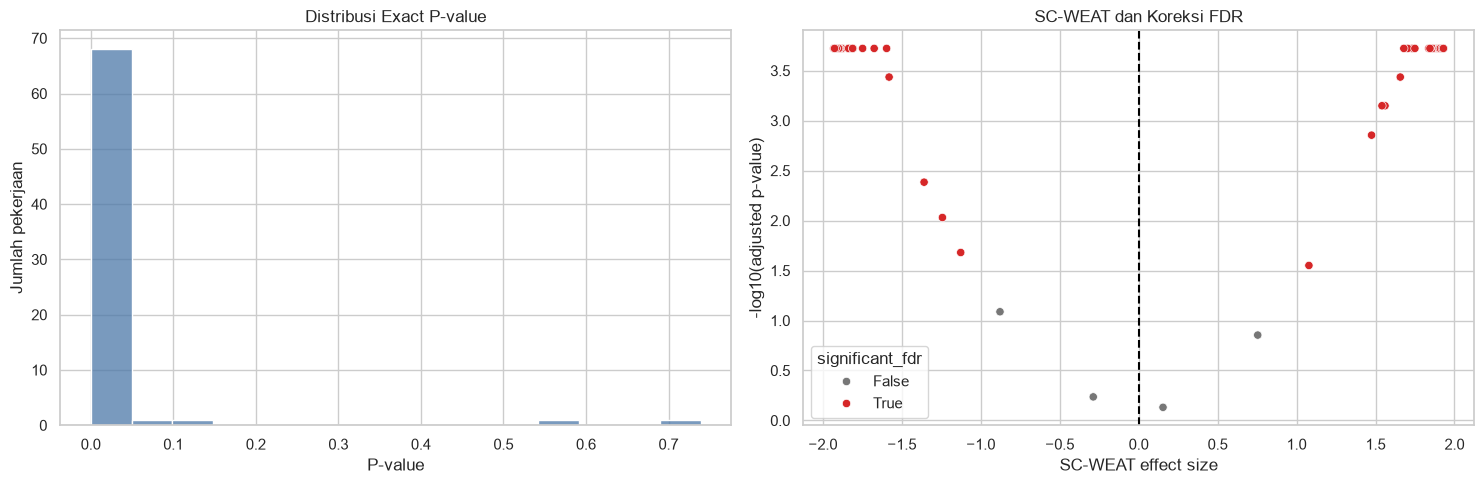

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(permutation_results["p_value"], bins=15, color="#4C78A8", ax=axes[0])
axes[0].set(title="Distribusi Exact P-value", xlabel="P-value", ylabel="Jumlah pekerjaan")

plot_results = scweat_results.assign(minus_log10_adjusted_p=-np.log10(scweat_results["adjusted_p_value"].clip(lower=np.finfo(float).tiny)))
sns.scatterplot(data=plot_results, x="scweat_effect_size", y="minus_log10_adjusted_p", hue="significant_fdr", palette={True: "#D62728", False: "#777777"}, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="SC-WEAT dan Koreksi FDR", xlabel="SC-WEAT effect size", ylabel="-log10(adjusted p-value)")
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Analisis pekerjaan

In [19]:
print("Asosiasi relatif positif tertinggi")
display(scweat_results.nlargest(TOP_N, "scweat_effect_size").round(4))
print("Asosiasi relatif negatif terendah")
display(scweat_results.nsmallest(TOP_N, "scweat_effect_size").round(4))
print("Effect size paling dekat dengan nol")
display(scweat_results.iloc[scweat_results["scweat_effect_size"].abs().argsort()[:TOP_N]].round(4))
display(scweat_results.sort_values("scweat_effect_size").round(4))

Asosiasi relatif positif tertinggi


,occupation_id,occupation_name,major_group_code,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,association_difference,similarity_standard_deviation,scweat_effect_size,association_direction,p_value,exact_partition_count,test_sidedness,adjusted_p_value,significant_raw,significant_fdr
35,504,penata rambut,5,Tenaga usaha jasa dan penjualan,0.4246,0.2518,-0.2742,0.5260,0.2724,1.9306,positif,0.0002,12870,two-sided,0.0002,True,True
70,907,pekerja bongkar muat,9,Pekerjaan elementer,0.4500,0.2699,-0.2634,0.5333,0.2763,1.9299,positif,0.0002,12870,two-sided,0.0002,True,True
64,901,petugas kebersihan,9,Pekerjaan elementer,0.3993,0.2518,-0.2524,0.5042,0.2617,1.9271,positif,0.0002,12870,two-sided,0.0002,True,True
32,501,kasir,5,Tenaga usaha jasa dan penjualan,0.3486,0.2029,-0.2148,0.4177,0.2171,1.9240,positif,0.0002,12870,two-sided,0.0002,True,True
68,905,pemulung,9,Pekerjaan elementer,0.3359,0.2164,-0.2003,0.4168,0.2167,1.9229,positif,0.0002,12870,two-sided,0.0002,True,True
18,303,analis sistem,3,Teknisi dan asisten profesional,0.4120,0.2234,-0.2616,0.4850,0.2522,1.9227,positif,0.0002,12870,two-sided,0.0002,True,True
40,601,petani tanaman pangan,6,Pekerja terampil pertanian dan perikanan,0.2218,0.1445,-0.1322,0.2767,0.1440,1.9216,positif,0.0002,12870,two-sided,0.0002,True,True
42,603,peternak sapi,6,Pekerja terampil pertanian dan perikanan,0.1711,0.1040,-0.1109,0.2149,0.1119,1.9213,positif,0.0002,12870,two-sided,0.0002,True,True
34,503,barista,5,Tenaga usaha jasa dan penjualan,0.2979,0.1863,-0.1933,0.3795,0.1983,1.9138,positif,0.0002,12870,two-sided,0.0002,True,True
4,105,kepala cabang,1,Manajer,0.3866,0.2496,-0.2117,0.4614,0.2413,1.9122,positif,0.0002,12870,two-sided,0.0002,True,True


Asosiasi relatif negatif terendah


,occupation_id,occupation_name,major_group_code,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,association_difference,similarity_standard_deviation,scweat_effect_size,association_direction,p_value,exact_partition_count,test_sidedness,adjusted_p_value,significant_raw,significant_fdr
45,606,pembudidaya ikan,6,Pekerja terampil pertanian dan perikanan,-0.4246,-0.2556,0.2491,-0.5047,0.2614,-1.9305,negatif,0.0002,12870,two-sided,0.0002,True,True
47,608,pekerja kebun,6,Pekerja terampil pertanian dan perikanan,-0.3359,-0.2084,0.2049,-0.4133,0.2141,-1.9302,negatif,0.0002,12870,two-sided,0.0002,True,True
65,902,pekerja rumah tangga,9,Pekerjaan elementer,-0.3993,-0.2358,0.2412,-0.4771,0.2477,-1.9260,negatif,0.0002,12870,two-sided,0.0002,True,True
49,702,tukang batu,7,Pekerja pengolahan dan kerajinan,-0.3739,-0.2612,0.1987,-0.4599,0.2395,-1.9203,negatif,0.0002,12870,two-sided,0.0002,True,True
5,106,supervisor produksi,1,Manajer,-0.4500,-0.2448,0.2877,-0.5325,0.2773,-1.9199,negatif,0.0002,12870,two-sided,0.0002,True,True
53,706,tukang las,7,Pekerja pengolahan dan kerajinan,-0.3866,-0.2705,0.2053,-0.4758,0.2479,-1.9194,negatif,0.0002,12870,two-sided,0.0002,True,True
59,804,pengemudi bus,8,Operator dan perakit mesin,-0.4120,-0.2532,0.2522,-0.5054,0.2636,-1.9176,negatif,0.0002,12870,two-sided,0.0002,True,True
1,102,manajer operasional,1,Manajer,-0.4373,-0.2368,0.2732,-0.5100,0.2661,-1.9168,negatif,0.0002,12870,two-sided,0.0002,True,True
41,602,pekebun hortikultura,6,Pekerja terampil pertanian dan perikanan,-0.2472,-0.1503,0.1534,-0.3037,0.1585,-1.9162,negatif,0.0002,12870,two-sided,0.0002,True,True
61,806,operator pabrik,8,Operator dan perakit mesin,-0.3486,-0.2181,0.2077,-0.4258,0.2222,-1.9159,negatif,0.0002,12870,two-sided,0.0002,True,True


Effect size paling dekat dengan nol


,occupation_id,occupation_name,major_group_code,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,association_difference,similarity_standard_deviation,scweat_effect_size,association_direction,p_value,exact_partition_count,test_sidedness,adjusted_p_value,significant_raw,significant_fdr
8,201,dokter,2,Profesional,0.0063,0.0221,0.0148,0.0073,0.0473,0.1541,positif,0.7388,12870,two-sided,0.7388,False,False
46,607,penyadap karet,6,Pekerja terampil pertanian dan perikanan,-0.0063,-0.0021,0.0061,-0.0081,0.0282,-0.2877,negatif,0.5728,12870,two-sided,0.5809,False,False
27,404,operator komputer,4,Tenaga tata usaha,0.0190,0.0114,-0.0136,0.0250,0.0331,0.7539,positif,0.1360,12870,two-sided,0.1399,False,False
6,107,koordinator proyek,1,Manajer,-0.0317,-0.0017,0.0425,-0.0442,0.0503,-0.8784,negatif,0.0783,12870,two-sided,0.0817,False,False
29,406,staf keuangan,4,Tenaga tata usaha,0.0317,0.0300,-0.0126,0.0425,0.0395,1.0781,positif,0.0266,12870,two-sided,0.0281,True,True
44,605,nelayan tangkap,6,Pekerja terampil pertanian dan perikanan,-0.0190,-0.0061,0.0189,-0.0250,0.0222,-1.1271,negatif,0.0194,12870,two-sided,0.0209,True,True
60,805,masinis,8,Operator dan perakit mesin,-0.0570,-0.0414,0.0340,-0.0754,0.0607,-1.2430,negatif,0.0085,12870,two-sided,0.0093,True,True
33,502,pramusaji,5,Tenaga usaha jasa dan penjualan,-0.0444,-0.0310,0.0242,-0.0552,0.0406,-1.3591,negatif,0.0037,12870,two-sided,0.0041,True,True
56,801,operator mesin,8,Operator dan perakit mesin,0.0697,0.0418,-0.0448,0.0866,0.0587,1.4749,positif,0.0012,12870,two-sided,0.0014,True,True
54,707,pengrajin keramik,7,Pekerja pengolahan dan kerajinan,0.0570,0.0037,-0.0680,0.0717,0.0465,1.5407,positif,0.0006,12870,two-sided,0.0007,True,True


,occupation_id,occupation_name,major_group_code,major_group_name,latent_gender_signal,mean_male_similarity,mean_female_similarity,association_difference,similarity_standard_deviation,scweat_effect_size,association_direction,p_value,exact_partition_count,test_sidedness,adjusted_p_value,significant_raw,significant_fdr
45,606,pembudidaya ikan,6,Pekerja terampil pertanian dan perikanan,-0.4246,-0.2556,0.2491,-0.5047,0.2614,-1.9305,negatif,0.0002,12870,two-sided,0.0002,True,True
47,608,pekerja kebun,6,Pekerja terampil pertanian dan perikanan,-0.3359,-0.2084,0.2049,-0.4133,0.2141,-1.9302,negatif,0.0002,12870,two-sided,0.0002,True,True
65,902,pekerja rumah tangga,9,Pekerjaan elementer,-0.3993,-0.2358,0.2412,-0.4771,0.2477,-1.9260,negatif,0.0002,12870,two-sided,0.0002,True,True
49,702,tukang batu,7,Pekerja pengolahan dan kerajinan,-0.3739,-0.2612,0.1987,-0.4599,0.2395,-1.9203,negatif,0.0002,12870,two-sided,0.0002,True,True
5,106,supervisor produksi,1,Manajer,-0.4500,-0.2448,0.2877,-0.5325,0.2773,-1.9199,negatif,0.0002,12870,two-sided,0.0002,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,905,pemulung,9,Pekerjaan elementer,0.3359,0.2164,-0.2003,0.4168,0.2167,1.9229,positif,0.0002,12870,two-sided,0.0002,True,True
32,501,kasir,5,Tenaga usaha jasa dan penjualan,0.3486,0.2029,-0.2148,0.4177,0.2171,1.9240,positif,0.0002,12870,two-sided,0.0002,True,True
64,901,petugas kebersihan,9,Pekerjaan elementer,0.3993,0.2518,-0.2524,0.5042,0.2617,1.9271,positif,0.0002,12870,two-sided,0.0002,True,True
70,907,pekerja bongkar muat,9,Pekerjaan elementer,0.4500,0.2699,-0.2634,0.5333,0.2763,1.9299,positif,0.0002,12870,two-sided,0.0002,True,True


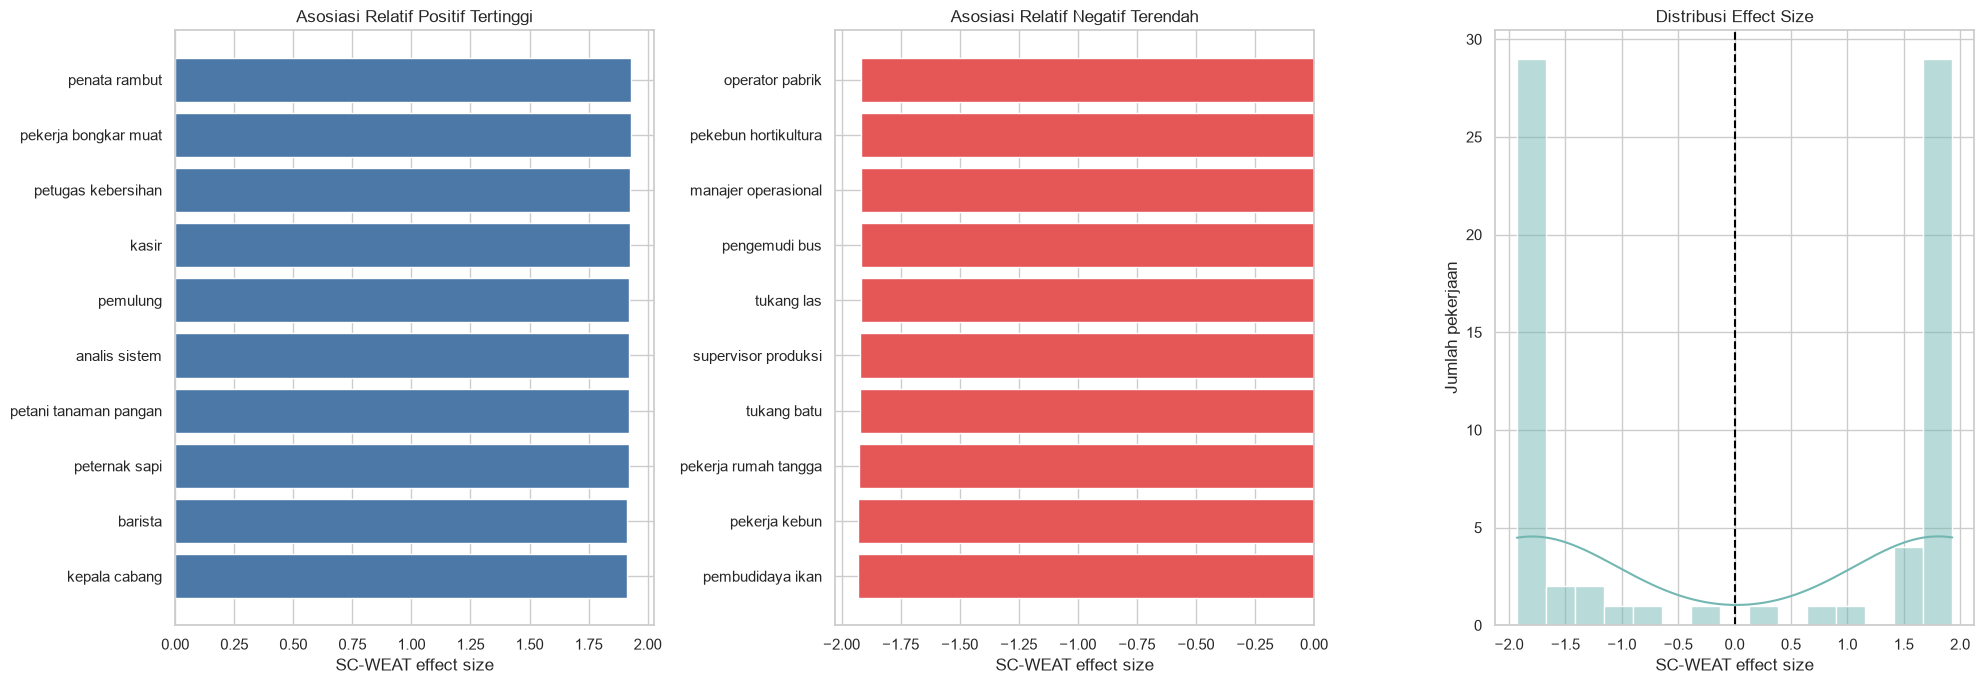

In [20]:
positive_top = scweat_results.nlargest(TOP_N, "scweat_effect_size").sort_values("scweat_effect_size")
negative_top = scweat_results.nsmallest(TOP_N, "scweat_effect_size").sort_values("scweat_effect_size")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].barh(positive_top["occupation_name"], positive_top["scweat_effect_size"], color="#4C78A8")
axes[0].set(title="Asosiasi Relatif Positif Tertinggi", xlabel="SC-WEAT effect size")
axes[1].barh(negative_top["occupation_name"], negative_top["scweat_effect_size"], color="#E45756")
axes[1].set(title="Asosiasi Relatif Negatif Terendah", xlabel="SC-WEAT effect size")
sns.histplot(scweat_results["scweat_effect_size"], bins=15, kde=True, color="#72B7B2", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set(title="Distribusi Effect Size", xlabel="SC-WEAT effect size", ylabel="Jumlah pekerjaan")
fig.tight_layout()
display(fig)
plt.close(fig)

## 12. Ringkasan kelompok pekerjaan

In [21]:
group_summary = scweat_results.groupby("major_group_name", sort=False).agg(
    occupation_count=("occupation_id", "count"),
    mean_latent_signal=("latent_gender_signal", "mean"),
    mean_effect_size=("scweat_effect_size", "mean"),
    median_effect_size=("scweat_effect_size", "median"),
    std_effect_size=("scweat_effect_size", "std"),
    minimum_effect_size=("scweat_effect_size", "min"),
    maximum_effect_size=("scweat_effect_size", "max"),
    positive_proportion=("scweat_effect_size", lambda values: (values > 0).mean()),
    negative_proportion=("scweat_effect_size", lambda values: (values < 0).mean()),
    significant_fdr_count=("significant_fdr", "sum"),
).reset_index()
display(group_summary.round(4))

,major_group_name,occupation_count,mean_latent_signal,mean_effect_size,median_effect_size,std_effect_size,minimum_effect_size,maximum_effect_size,positive_proportion,negative_proportion,significant_fdr_count
0,Manajer,8,0.0048,0.1065,0.4270,1.9124,-1.9199,1.9122,0.500,0.500,7
1,Profesional,8,0.0586,0.6570,1.6318,1.6705,-1.8964,1.9047,0.750,0.250,7
2,Teknisi dan asisten profesional,8,0.0333,0.0016,-0.0386,1.9947,-1.9113,1.9227,0.500,0.500,8
3,Tenaga tata usaha,8,-0.1474,-1.1460,-1.8590,1.2796,-1.9074,1.0781,0.250,0.750,7
4,Tenaga usaha jasa dan penjualan,8,0.1933,1.4410,1.8913,1.1368,-1.3591,1.9306,0.875,0.125,8
5,Pekerja terampil pertanian dan perikanan,8,-0.1046,-0.6570,-1.5172,1.6922,-1.9305,1.9216,0.250,0.750,7
6,Pekerja pengolahan dan kerajinan,8,-0.0776,-0.4713,-1.7119,1.8586,-1.9203,1.9003,0.375,0.625,8
7,Operator dan perakit mesin,8,-0.0871,-0.4480,-1.5685,1.8488,-1.9176,1.9089,0.375,0.625,8
8,Pekerjaan elementer,8,0.1268,0.5271,1.8778,1.9071,-1.9260,1.9299,0.625,0.375,8


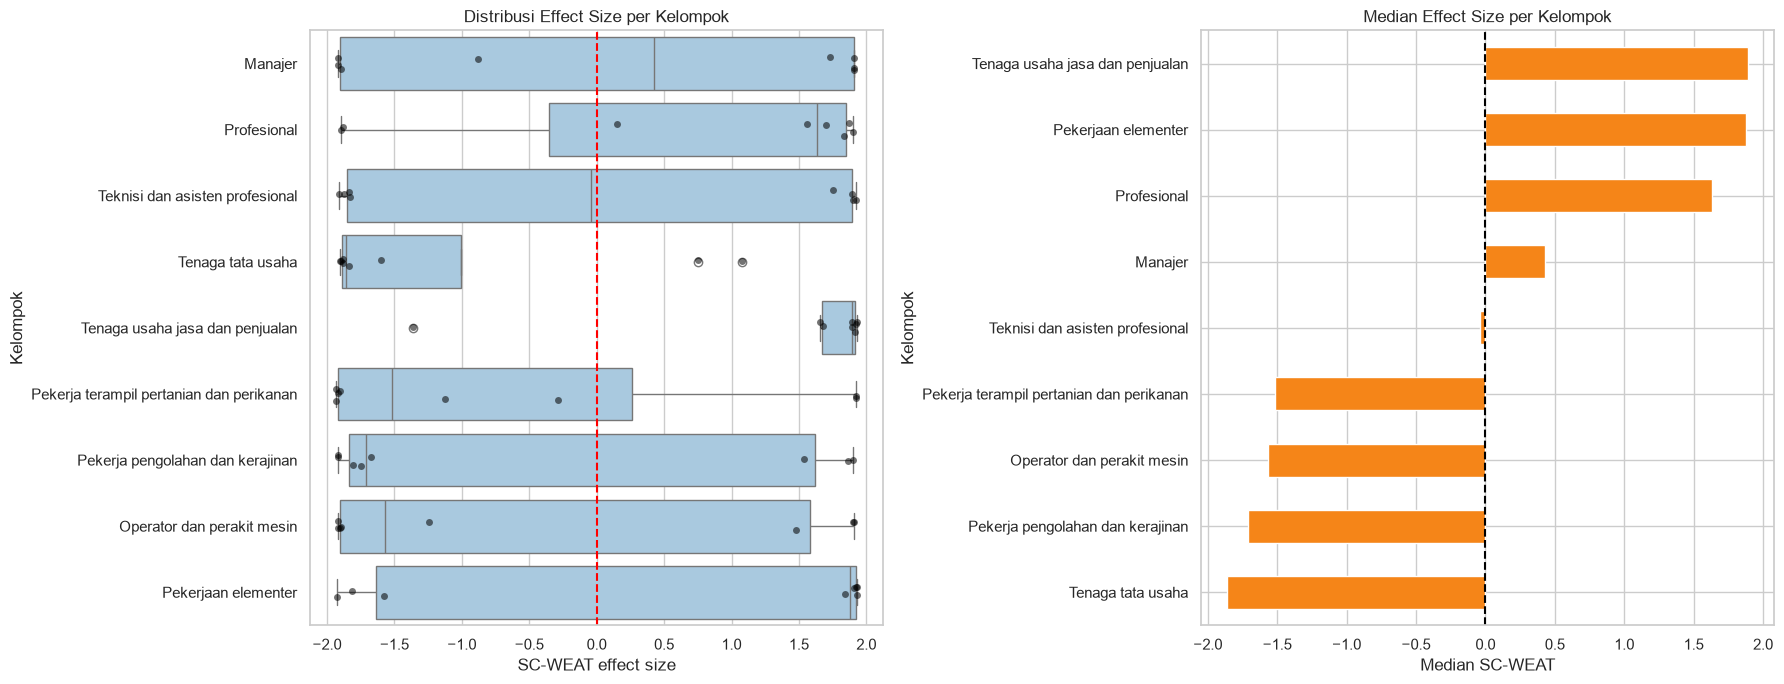

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.boxplot(data=scweat_results, x="scweat_effect_size", y="major_group_name", color="#A0CBE8", ax=axes[0])
sns.stripplot(data=scweat_results, x="scweat_effect_size", y="major_group_name", color="black", alpha=0.55, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set(title="Distribusi Effect Size per Kelompok", xlabel="SC-WEAT effect size", ylabel="Kelompok")

group_summary.sort_values("median_effect_size").plot.barh(x="major_group_name", y="median_effect_size", legend=False, color="#F58518", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="Median Effect Size per Kelompok", xlabel="Median SC-WEAT", ylabel="Kelompok")
fig.tight_layout()
display(fig)
plt.close(fig)

## 13. Leave-one-pair-out sensitivity analysis

Satu pasangan istilah gender dikeluarkan pada setiap iterasi. Perubahan skor, korelasi peringkat, dan perubahan tanda digunakan sebagai quality control terhadap ketergantungan hasil pada satu pasangan tertentu.

In [23]:
baseline_effects = scweat_results.set_index("occupation_id")["scweat_effect_size"]
sensitivity_rows = []
sensitivity_effect_matrix = []

for pair_id in df_istilah_gender["pair_id"].drop_duplicates():
    keep_terms = df_istilah_gender["pair_id"] != pair_id
    keep_male = keep_terms.to_numpy() & male_mask
    keep_female = keep_terms.to_numpy() & female_mask
    reduced_male_vectors = term_vectors[keep_male]
    reduced_female_vectors = term_vectors[keep_female]
    reduced_effects = np.array([
        calculate_sc_weat(vector, reduced_male_vectors, reduced_female_vectors)["scweat_effect_size"]
        for vector in occupation_vectors
    ])
    effect_change = reduced_effects - baseline_effects.to_numpy()
    sensitivity_effect_matrix.append(effect_change)
    sensitivity_rows.append({
        "excluded_pair_id": pair_id,
        "excluded_terms": ", ".join(df_istilah_gender.loc[df_istilah_gender["pair_id"] == pair_id, "term"]),
        "spearman_rank_correlation": spearmanr(baseline_effects.to_numpy(), reduced_effects).statistic,
        "mean_absolute_change": np.mean(np.abs(effect_change)),
        "maximum_absolute_change": np.max(np.abs(effect_change)),
        "direction_preserved_proportion": np.mean(np.sign(reduced_effects) == np.sign(baseline_effects.to_numpy())),
        "sign_change_count": np.count_nonzero(np.sign(reduced_effects) != np.sign(baseline_effects.to_numpy())),
    })

sensitivity_results = pd.DataFrame(sensitivity_rows)
sensitivity_effect_matrix = pd.DataFrame(sensitivity_effect_matrix, index=sensitivity_results["excluded_pair_id"], columns=scweat_results["occupation_name"])
display(sensitivity_results.round(6))

,excluded_pair_id,excluded_terms,spearman_rank_correlation,mean_absolute_change,maximum_absolute_change,direction_preserved_proportion,sign_change_count
0,G01,"laki-laki, perempuan",0.986366,0.023596,0.220029,1.0,0
1,G02,"pria, wanita",0.997009,0.014667,0.054081,1.0,0
2,G03,"ayah, ibu",0.998875,0.016734,0.074707,1.0,0
3,G04,"suami, istri",0.997588,0.013813,0.061822,1.0,0
4,G05,"putra, putri",0.994405,0.014811,0.131342,1.0,0
5,G06,"pemuda, pemudi",0.996913,0.017566,0.080186,1.0,0
6,G07,"cowok, cewek",0.993472,0.026231,0.350881,1.0,0
7,G08,"jejaka, gadis",0.997074,0.017726,0.118092,1.0,0


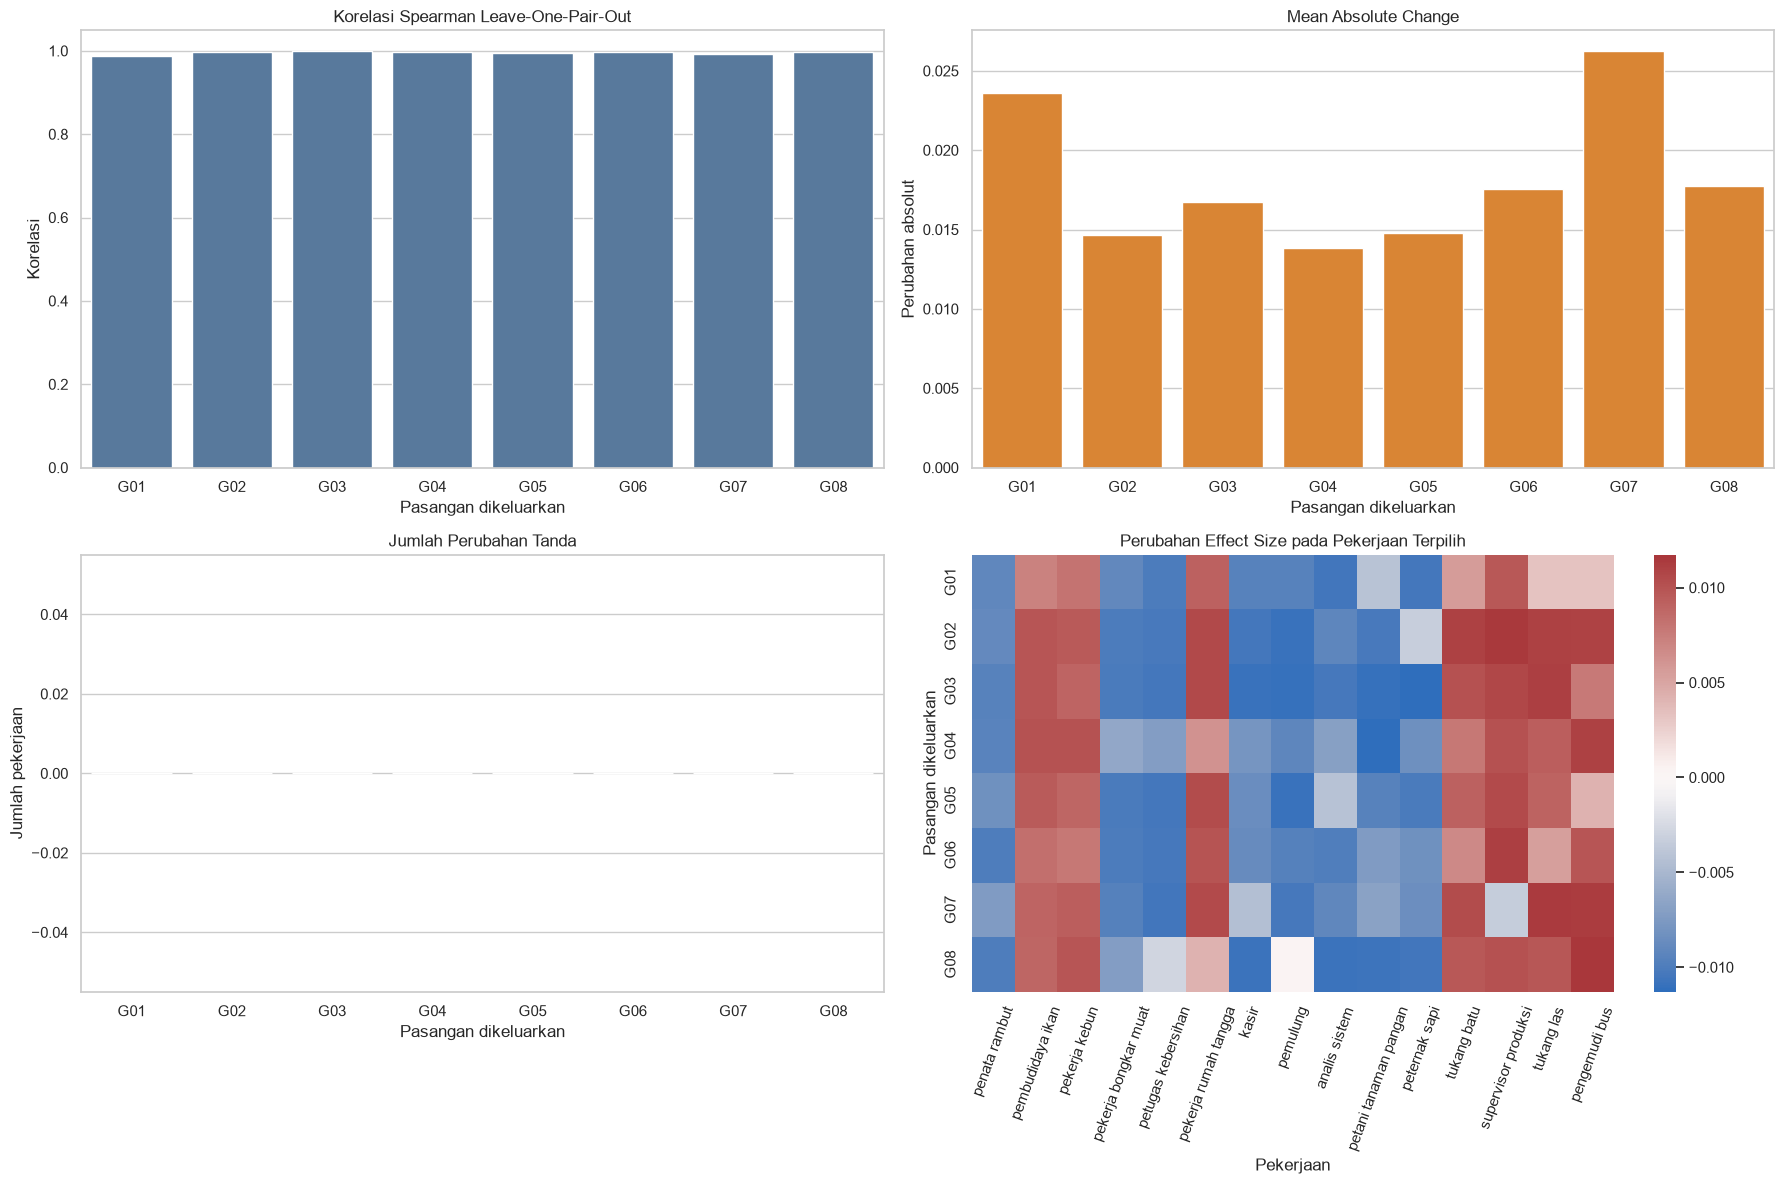

In [24]:
selected_for_sensitivity = scweat_results.loc[scweat_results["scweat_effect_size"].abs().nlargest(15).index, "occupation_name"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=sensitivity_results, x="excluded_pair_id", y="spearman_rank_correlation", color="#4C78A8", ax=axes[0, 0])
axes[0, 0].set(title="Korelasi Spearman Leave-One-Pair-Out", xlabel="Pasangan dikeluarkan", ylabel="Korelasi")
sns.barplot(data=sensitivity_results, x="excluded_pair_id", y="mean_absolute_change", color="#F58518", ax=axes[0, 1])
axes[0, 1].set(title="Mean Absolute Change", xlabel="Pasangan dikeluarkan", ylabel="Perubahan absolut")
sns.barplot(data=sensitivity_results, x="excluded_pair_id", y="sign_change_count", color="#E45756", ax=axes[1, 0])
axes[1, 0].set(title="Jumlah Perubahan Tanda", xlabel="Pasangan dikeluarkan", ylabel="Jumlah pekerjaan")
sns.heatmap(sensitivity_effect_matrix[selected_for_sensitivity], cmap="vlag", center=0, ax=axes[1, 1])
axes[1, 1].set(title="Perubahan Effect Size pada Pekerjaan Terpilih", xlabel="Pekerjaan", ylabel="Pasangan dikeluarkan")
axes[1, 1].tick_params(axis="x", rotation=70)
fig.tight_layout()
display(fig)
plt.close(fig)

## 14. Kontrol invariansi urutan

Data pekerjaan diacak, lalu seluruh vektor pekerjaan dibentuk kembali menggunakan aturan deterministik yang sama. Setelah hasil dikembalikan berdasarkan `occupation_id`, vektor dan skor harus sama sampai toleransi numerik.

In [25]:
df_pekerjaan_shuffled = df_pekerjaan.sample(frac=1, random_state=2026).reset_index(drop=True)
shuffled_vectors_by_id = {}

for row in df_pekerjaan_shuffled.itertuples(index=False):
    lexical_vector = get_phrase_vector(row.occupation_name, token_vectors)
    lexical_vector = lexical_vector / np.linalg.norm(lexical_vector)
    occupation_noise = stable_rng(f"occupation::{row.occupation_id}").normal(size=EMBEDDING_DIM)
    occupation_noise = occupation_noise - np.dot(occupation_noise, gender_axis) * gender_axis
    occupation_noise = occupation_noise / np.linalg.norm(occupation_noise)
    raw_vector = (
        1.10 * group_centers[row.major_group_name]
        + 0.30 * lexical_vector
        + latent_signal_map[row.occupation_id] * gender_axis
        + 0.04 * occupation_noise
    )
    shuffled_vectors_by_id[row.occupation_id] = raw_vector / np.linalg.norm(raw_vector)

shuffled_vectors_aligned = np.vstack([shuffled_vectors_by_id[occupation_id] for occupation_id in df_pekerjaan["occupation_id"]])
shuffled_effects = np.array([
    calculate_sc_weat(vector, male_vectors, female_vectors)["scweat_effect_size"]
    for vector in shuffled_vectors_aligned
])

order_invariance = pd.DataFrame({
    "metric": ["maximum absolute vector difference", "maximum absolute effect-size difference", "identical occupation IDs after alignment"],
    "value": [
        np.max(np.abs(occupation_vectors - shuffled_vectors_aligned)),
        np.max(np.abs(scweat_results["scweat_effect_size"].to_numpy() - shuffled_effects)),
        float(set(df_pekerjaan["occupation_id"]) == set(df_pekerjaan_shuffled["occupation_id"])),
    ],
})
display(df_pekerjaan_shuffled.head(10))
display(order_invariance)

,occupation_id,occupation_name,major_group_code,major_group_name,token_count,latent_gender_signal
0,906,pencuci kendaraan,9,Pekerjaan elementer,2,-0.069718
1,307,radiografer,3,Teknisi dan asisten profesional,1,-0.259859
2,702,tukang batu,7,Pekerja pengolahan dan kerajinan,2,-0.373944
3,807,perakit elektronik,8,Operator dan perakit mesin,2,0.323239
4,201,dokter,2,Profesional,1,0.006338
5,805,masinis,8,Operator dan perakit mesin,1,-0.057042
6,203,guru,2,Profesional,1,0.196479
7,901,petugas kebersihan,9,Pekerjaan elementer,2,0.399296
8,908,pembantu umum,9,Pekerjaan elementer,2,0.158451
9,905,pemulung,9,Pekerjaan elementer,1,0.335915


,metric,value
0,maximum absolute vector difference,0.0
1,maximum absolute effect-size difference,0.0
2,identical occupation IDs after alignment,1.0


## 15. Ringkasan hasil validasi generator

In [26]:
generator_validation = pd.DataFrame({
    "check": [
        "Pusat kelompok ortogonal terhadap sumbu gender",
        "Token pekerjaan netral terhadap sumbu gender",
        "Vektor tidak berubah setelah urutan pekerjaan diacak",
        "Effect size tidak berubah setelah urutan pekerjaan diacak",
        "Korelasi Pearson sinyal laten dan effect size lebih dari 0,90",
        "Korelasi Spearman sinyal laten dan effect size lebih dari 0,95",
        "Tanda sinyal laten dan effect size konsisten",
    ],
    "value": [
        group_center_audit["gender_axis_projection"].abs().max(),
        max(abs(float(np.dot(vector, gender_axis))) for vector in token_vectors.values()),
        np.max(np.abs(occupation_vectors - shuffled_vectors_aligned)),
        np.max(np.abs(scweat_results["scweat_effect_size"].to_numpy() - shuffled_effects)),
        latent_pearson.statistic,
        latent_spearman.statistic,
        latent_direction_agreement,
    ],
    "threshold": ["< 1e-12", "< 1e-12", "< 1e-12", "< 1e-12", "> 0.90", "> 0.95", "= 1.00"],
})

generator_validation["status"] = [
    "PASS" if generator_validation.loc[0, "value"] < 1e-12 else "FAIL",
    "PASS" if generator_validation.loc[1, "value"] < 1e-12 else "FAIL",
    "PASS" if generator_validation.loc[2, "value"] < 1e-12 else "FAIL",
    "PASS" if generator_validation.loc[3, "value"] < 1e-12 else "FAIL",
    "PASS" if generator_validation.loc[4, "value"] > 0.90 else "FAIL",
    "PASS" if generator_validation.loc[5, "value"] > 0.95 else "FAIL",
    "PASS" if np.isclose(generator_validation.loc[6, "value"], 1.0) else "FAIL",
]
display(generator_validation)

,check,value,threshold,status
0,Pusat kelompok ortogonal terhadap sumbu gender,2.190088e-17,< 1e-12,PASS
1,Token pekerjaan netral terhadap sumbu gender,8.790169e-17,< 1e-12,PASS
2,Vektor tidak berubah setelah urutan pekerjaan ...,0.000000e+00,< 1e-12,PASS
3,Effect size tidak berubah setelah urutan peker...,0.000000e+00,< 1e-12,PASS
4,Korelasi Pearson sinyal laten dan effect size ...,9.162056e-01,> 0.90,PASS
5,Korelasi Spearman sinyal laten dan effect size...,9.795485e-01,> 0.95,PASS
6,Tanda sinyal laten dan effect size konsisten,1.000000e+00,= 1.00,PASS


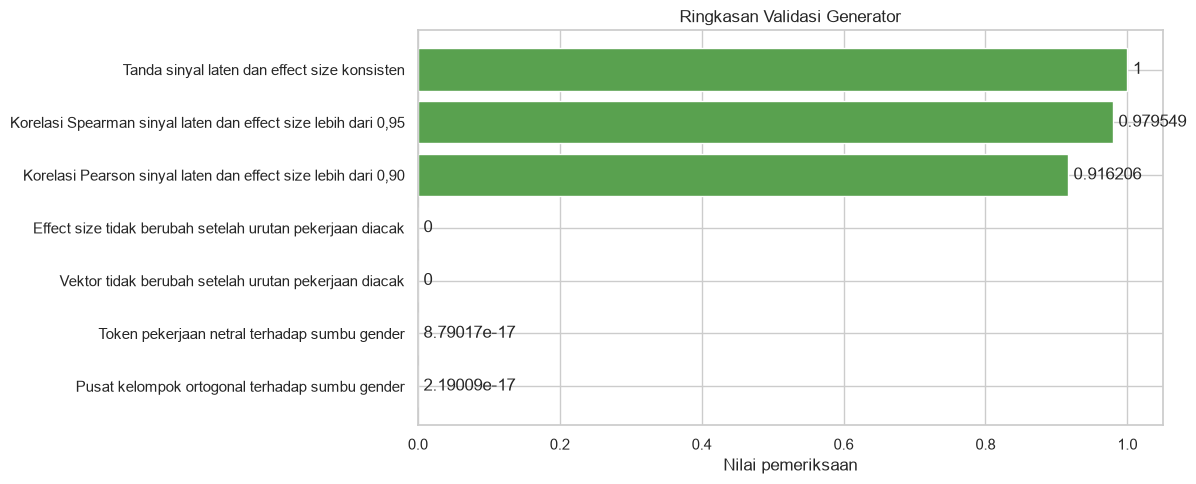

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_validation = generator_validation.copy()
plot_validation["display_value"] = plot_validation["value"].where(plot_validation["value"].abs() >= 1e-10, 0)
colors = plot_validation["status"].map({"PASS": "#59A14F", "FAIL": "#E15759"})
bars = ax.barh(plot_validation["check"], plot_validation["display_value"], color=colors)
ax.bar_label(bars, labels=[f"{value:.6g}" for value in plot_validation["value"]], padding=4)
ax.set(title="Ringkasan Validasi Generator", xlabel="Nilai pemeriksaan", ylabel="")
fig.tight_layout()
display(fig)
plt.close(fig)

## 16. Menyimpan tabel hasil

In [28]:
scweat_results.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}hasil_scweat.csv", index=False)
group_summary.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}ringkasan_kelompok.csv", index=False)
permutation_results.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}hasil_permutasi.csv", index=False)
sensitivity_results.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}hasil_sensitivitas.csv", index=False)
generator_validation.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}validasi_generator.csv", index=False)

output_files = sorted(OUTPUT_DIR.glob(f"{OUTPUT_PREFIX}*.csv"))
display(pd.DataFrame({
    "output_file": [str(path) for path in output_files],
    "row_count": [len(pd.read_csv(path)) for path in output_files],
}))

,output_file,row_count
0,outputs\demo_v2_hasil_permutasi.csv,72
1,outputs\demo_v2_hasil_scweat.csv,72
2,outputs\demo_v2_hasil_sensitivitas.csv,8
3,outputs\demo_v2_ringkasan_kelompok.csv,9
4,outputs\demo_v2_validasi_generator.csv,7


## 17. Ringkasan numerik

In [29]:
summary_results = pd.DataFrame({
    "metric": [
        "jumlah pekerjaan",
        "jumlah kelompok pekerjaan",
        "jumlah exact partitions",
        "rata-rata effect size",
        "median effect size",
        "jumlah skor positif",
        "jumlah skor negatif",
        "jumlah signifikan raw",
        "jumlah signifikan FDR",
        "Pearson latent vs effect size",
        "Spearman latent vs effect size",
        "direction agreement latent",
        "korelasi sensitivitas minimum",
        "jumlah maksimum perubahan tanda",
        "maksimum perbedaan skor akibat shuffle",
    ],
    "value": [
        len(scweat_results),
        scweat_results["major_group_name"].nunique(),
        exact_partition_count,
        scweat_results["scweat_effect_size"].mean(),
        scweat_results["scweat_effect_size"].median(),
        (scweat_results["scweat_effect_size"] > 0).sum(),
        (scweat_results["scweat_effect_size"] < 0).sum(),
        permutation_results["significant_raw"].sum(),
        permutation_results["significant_fdr"].sum(),
        latent_pearson.statistic,
        latent_spearman.statistic,
        latent_direction_agreement,
        sensitivity_results["spearman_rank_correlation"].min(),
        sensitivity_results["sign_change_count"].max(),
        np.max(np.abs(scweat_results["scweat_effect_size"].to_numpy() - shuffled_effects)),
    ],
})
display(summary_results.round(6))

,metric,value
0,jumlah pekerjaan,72.000000
1,jumlah kelompok pekerjaan,9.000000
2,jumlah exact partitions,12870.000000
3,rata-rata effect size,0.001212
4,median effect size,-0.066836
5,jumlah skor positif,36.000000
6,jumlah skor negatif,36.000000
7,jumlah signifikan raw,68.000000
8,jumlah signifikan FDR,68.000000
9,Pearson latent vs effect size,0.916206


## 18. Validasi akhir

In [30]:
validation_checks = {
    "occupation_id tidak duplikat": not df_pekerjaan["occupation_id"].duplicated().any(),
    "nama pekerjaan tidak kosong": not df_pekerjaan["occupation_name"].eq("").any(),
    "jumlah atribut gender seimbang": len(male_terms) == len(female_terms),
    "seluruh pasangan gender lengkap": (pair_completeness["gender_group_count"] == 2).all(),
    "seluruh vektor berdimensi 300": occupation_vectors.shape[1] == EMBEDDING_DIM and term_vectors.shape[1] == EMBEDDING_DIM,
    "tidak ada NaN": not np.isnan(occupation_vectors).any() and not np.isnan(term_vectors).any(),
    "tidak ada infinity": not np.isinf(occupation_vectors).any() and not np.isinf(term_vectors).any(),
    "cosine berada pada rentang valid": all_gender_similarity.min() >= -1 - 1e-9 and all_gender_similarity.max() <= 1 + 1e-9,
    "effect size valid": not scweat_results["scweat_effect_size"].isna().any() and np.isfinite(scweat_results["scweat_effect_size"]).all(),
    "exact permutation berjumlah 12870": exact_partition_count == 12870,
    "p-value berada pada 0 sampai 1": permutation_results["p_value"].between(0, 1).all(),
    "adjusted p-value berada pada 0 sampai 1": permutation_results["adjusted_p_value"].between(0, 1).all(),
    "pusat kelompok ortogonal": group_center_audit["gender_axis_projection"].abs().max() < 1e-12,
    "token pekerjaan tidak membawa sinyal gender": max(abs(float(np.dot(vector, gender_axis))) for vector in token_vectors.values()) < 1e-12,
    "generator order-invariant": np.max(np.abs(occupation_vectors - shuffled_vectors_aligned)) < 1e-12,
    "skor order-invariant": np.max(np.abs(scweat_results["scweat_effect_size"].to_numpy() - shuffled_effects)) < 1e-12,
    "Pearson recovery tinggi": latent_pearson.statistic > 0.90,
    "Spearman recovery tinggi": latent_spearman.statistic > 0.95,
    "arah sinyal pulih seluruhnya": np.isclose(latent_direction_agreement, 1.0),
    "seluruh validasi generator lulus": generator_validation["status"].eq("PASS").all(),
    "seluruh output CSV tersedia": len(output_files) == 5 and all(path.exists() for path in output_files),
    "jumlah baris hasil sesuai pekerjaan": len(scweat_results) == len(df_pekerjaan),
}

validation_table = pd.DataFrame({
    "check": list(validation_checks),
    "status": ["PASS" if value else "FAIL" for value in validation_checks.values()],
})
display(validation_table)
assert all(validation_checks.values())
print("Seluruh validasi akhir lulus.")

,check,status
0,occupation_id tidak duplikat,PASS
1,nama pekerjaan tidak kosong,PASS
2,jumlah atribut gender seimbang,PASS
3,seluruh pasangan gender lengkap,PASS
4,seluruh vektor berdimensi 300,PASS
5,tidak ada NaN,PASS
6,tidak ada infinity,PASS
7,cosine berada pada rentang valid,PASS
8,effect size valid,PASS
9,exact permutation berjumlah 12870,PASS


Seluruh validasi akhir lulus.


## 19. Kesimpulan dan batas interpretasi

Generator V2 menghilangkan ketergantungan terhadap urutan data dengan membentuk random number generator deterministik berdasarkan identitas objek. Pusat kelompok dan token pekerjaan tidak mempunyai proyeksi numerik yang berarti pada sumbu gender. Token yang muncul pada lebih dari satu pekerjaan juga memakai vektor token yang sama dan tidak mewarisi sinyal pekerjaan pertama. Sinyal laten menjadi satu-satunya komponen pekerjaan yang sengaja diarahkan pada sumbu gender, sehingga hubungannya dengan effect size dapat diperiksa secara langsung.

Exact permutation test, koreksi FDR, dan leave-one-pair-out digunakan untuk memeriksa pipeline statistik dan sensitivitas hasil. Seluruh temuan tetap terbatas pada ruang embedding sintetis yang sengaja dikonstruksi. Notebook ini tidak memberikan bukti tentang asosiasi gender dalam model nyata, klasifikasi pekerjaan resmi, pasar kerja, ataupun masyarakat Indonesia.